# Selective Inference for Time-Varying Moderated Effects

Simulation study and VALENTINE data application for
*"Selective Inference for Time-Varying Moderated Effects"* (Bakshi, Dempsey, Panigrahi).

Four methods are compared throughout:

| Method | Description |
|---|---|
| **Randomized SI** (ours) | randomized lasso + conditional selective inference |
| **Polyhedral** | Lee et al. (2016), via R `selectiveInference::fixedLassoInf` |
| **Naive GEE** | robust sandwich intervals after lasso selection (no SI correction) |
| **Data splitting** | lasso on a train split, GEE inference on a held-out test split |


## Setup

The next two cells define the whole engine: the simulation runner
(`compwl_inf`, `run_compwl_grid`, conditional-coverage and seed-stability
drivers) and the plotting helpers. Run them once, then run any figure cell
below independently.

In [2]:
"""
Simulation runner for comparing selective inference methods on MRT data.

Methods compared:
    1. Polyhedral (Lee et al. 2016) — via R's selectiveInference::fixedLassoInf
    2. Naive GEE — robust sandwich intervals after lasso selection (no SI correction)
    3. Randomized SI (our method) — randomized lasso + conditional selective inference
    4. Data splitting — lasso on train split, GEE inference on test split

Paper: "Selective Inference for Time-Varying Moderated Effects"
       Bakshi, Dempsey, Panigrahi (JASA revision)

Key design choices (matching paper Section 5):
    - Penalty lambda: median of max|X^T eps| where eps ~ N(0, sigma_hat^2 I)
      (Negahban et al. 2012 prescription)
    - Randomization: omega ~ N(0, tau^2 I_p) with tau = sigma_hat
    - Dispersion: sigma_hat^2 (estimated variance of residualized response)
    - sigma_hat comes from MRT_instance's nuisance estimation step
"""

from MRT_instance import MRT_instance
from selectinf.lasso import lasso
from selectinf.Utils.base import selected_targets_WCLS

import rpy2.rinterface as ri
from rpy2.robjects import numpy2ri
from rpy2.robjects.packages import importr

numpy2ri.activate()
selectiveInference = importr("selectiveInference")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn import linear_model
from tqdm import tqdm


# ============================================================
# Helper functions
# ============================================================


def _score_penalty(X, Y, sigma, multiplier=1.0, n_score_draws=2000):
    """
    Penalty lambda via Negahban et al. (2012) prescription.

    lambda = multiplier * median_over_draws( max_j |X_j^T eps| )

    where eps ~ N(0, sigma^2 I_n).

    Parameters
    ----------
    sigma : float
        Noise SD estimate (sigma_hat from MRT_instance).
        Paper: "sigma_hat^2 is the estimated variance of the response."
    """
    n, p = X.shape
    eps = np.random.standard_normal((n, n_score_draws)) * sigma
    W = multiplier * np.median(np.max(np.abs(X.T @ eps), axis=0))
    return W


def _selection_metrics(selected, beta):
    """
    Selection quality metrics: TP, precision, recall, F1.
    """
    selected = np.asarray(selected, dtype=bool)
    true_nonzero = beta != 0

    tp = int(np.sum(selected & true_nonzero))
    n_selected = int(np.sum(selected))
    n_true = int(np.sum(true_nonzero))

    precision = tp / n_selected if n_selected > 0 else np.nan
    recall = tp / n_true if n_true > 0 else np.nan
    f1 = 2 * tp / (n_selected + n_true) if (n_selected + n_true) > 0 else np.nan

    return {
        "tp": tp,
        "n_selected": n_selected,
        "n_true": n_true,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def _method_record(method, selected, beta, coverage, length, target=None, intervals=None):
    """Standardized output for one method in one MC replication."""
    selected = np.asarray(selected, dtype=bool)
    coverage = np.asarray(coverage, dtype=bool)
    length = np.asarray(length, dtype=float)

    metrics = _selection_metrics(selected, beta)
    finite_length = length[np.isfinite(length)]

    return {
        "method": method,
        "selected": selected,
        "selected_idx": np.flatnonzero(selected),
        "coverage": coverage,
        "coverage_mean": np.mean(coverage) if len(coverage) > 0 else np.nan,
        "length": length,
        "length_mean": np.mean(length) if len(length) > 0 else np.nan,
        "finite_length": finite_length,
        "finite_length_mean": np.mean(finite_length) if len(finite_length) > 0 else np.nan,
        "finite_length_rate": np.mean(np.isfinite(length)) if len(length) > 0 else np.nan,
        "target": target,
        "intervals": intervals,
        **metrics,
    }


def _gee_intervals(A_df, selected, beta_target, alpha=0.1):
    """
    Robust GEE confidence intervals (sandwich variance) on selected columns.
    """
    Xf = np.array(A_df.iloc[:, 2:-1])[:, selected]
    yf = A_df["Y"]
    groups = A_df["id"]

    model = sm.GEE(
        yf, Xf, groups=groups,
        family=sm.families.Gaussian(),
        cov_struct=sm.cov_struct.Independence(),
    )
    result = model.fit(cov_type="robust")

    intervals = np.asarray(result.conf_int(alpha=alpha))
    lci, uci = intervals[:, 0], intervals[:, 1]

    coverage = (lci < beta_target) & (uci > beta_target)
    length = uci - lci

    return coverage, length, intervals


def _split_ids(A_df, test_prop=0.3, seed=None):
    """
    Random train/test split by individual ID.

    Parameters
    ----------
    seed : int or None
        If None, uses a fresh random split each call.
        Pass a seed for reproducibility within a replication.
    """
    unique_ids = A_df["id"].unique()
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(unique_ids).tolist()

    train_size = int((1 - test_prop) * len(shuffled))
    return shuffled[:train_size], shuffled[train_size:]


# ============================================================
# Main simulation: compare 4 methods
# ============================================================


def compwl_inf(
    N=60,
    beta_11=0.4,
    test_prop=0.3,
    randomizer_scale=1.0,
    penalty_multiplier=1.0,
    n_score_draws=2000,
    max_attempts=None,
    split_seed=None,
    mrt_kwargs=None,
):
    """
    One MC replication: generate MRT data, run 4 inference methods.

    Parameters
    ----------
    N : int
        Number of individuals passed to MRT_instance.
    beta_11 : float
        Per-coordinate signal strength for active moderators.
    test_prop : float
        Fraction of analysis individuals used as test set in data splitting.
    randomizer_scale : float
        Multiplier for randomization level.
        Actual tau = randomizer_scale * sqrt(mean_diag) * sigma_hat,
        matching the selectinf gradient scale. Paper uses 1.0 ("moderate").
    penalty_multiplier : float
        Multiplier for the Negahban penalty. Paper: 1.0.
    n_score_draws : int
        Number of draws for the score-based penalty estimate.
    max_attempts : int or None
        Max retries if lasso selects nothing. None = unlimited.
    split_seed : int or None
        Seed for the data-splitting train/test partition.
        If None, a fresh random split each replication.
    mrt_kwargs : dict or None
        Extra keyword arguments to MRT_instance (e.g., nuisance, error_dist).

    Returns
    -------
    dict with keys: status, meta, beta, methods
        methods contains records for: polyhedral, naive_gee, randomized_si, data_splitting
    """
    if mrt_kwargs is None:
        mrt_kwargs = {}

    attempt = 0

    while True:
        attempt += 1

        if max_attempts is not None and attempt > max_attempts:
            return {
                "status": "failed",
                "reason": "max_attempts_exceeded",
                "meta": {
                    "N": N, "beta_11": beta_11,
                    "attempt": attempt - 1,
                },
                "methods": {},
            }

        # ── Data generation ────────────────────────────────────────
        X, Y, beta, A, sigma_hat = MRT_instance(
            N=N, beta_11=beta_11, **mrt_kwargs,
        )

        n, p = X.shape

        # ── Penalty (Negahban et al.) ──────────────────────────────
        # lambda = multiplier * median(max|X^T eps|), eps ~ N(0, sigma_hat^2 I)
        W = _score_penalty(X, Y, sigma=sigma_hat,
                           multiplier=penalty_multiplier,
                           n_score_draws=n_score_draws)

        # ============================================================
        # 1. Polyhedral method (Lee et al. 2016)
        # ============================================================
        slf = linear_model.Lasso(alpha=W / n, fit_intercept=False)
        slf.fit(X, Y)
        nonzerop = slf.coef_ != 0

        if nonzerop.sum() == 0:
            continue

        beta_targetp = np.linalg.pinv(X[:, nonzerop]).dot(X.dot(beta))

        results_r = selectiveInference.fixedLassoInf(
            X, Y, slf.coef_, lam=W, sigma=sigma_hat,
        )

        if results_r is ri.NULL or isinstance(results_r, ri.NULLType):
            continue

        ci_r = results_r.rx2("ci")
        if ci_r is ri.NULL or isinstance(ci_r, ri.NULLType):
            continue
        pci = np.asarray(ci_r)

        if pci.shape[0] != nonzerop.sum():
            continue

        coveragep = (pci[:, 0] < beta_targetp) & (pci[:, 1] > beta_targetp)
        lengthp = pci[:, 1] - pci[:, 0]

        poly_record = _method_record(
            "polyhedral", nonzerop, beta, coveragep, lengthp,
            target=beta_targetp, intervals=pci,
        )

        # ============================================================
        # 2. Naive GEE (no SI correction — should undercover)
        # ============================================================
        cov2, len2, gee_iv = _gee_intervals(A, nonzerop, beta_targetp, alpha=0.1)

        naive_record = _method_record(
            "naive_gee", nonzerop, beta, cov2, len2,
            target=beta_targetp, intervals=gee_iv,
        )

        # ============================================================
        # 3. Randomized SI (our method)
        # ============================================================
        # selectinf's lasso.gaussian uses loss = (1/2σ²)||Y-Xβ||²
        # and divides feature_weights by σ², but does NOT rescale
        # the randomizer. Its default is τ = √mean_diag * 0.5 * SD(Y),
        # which is O(√n). We match this convention:
        #   τ = randomizer_scale * √mean_diag * σ_hat
        # so randomizer_scale=1 gives "moderate" randomization
        # comparable to the gradient scale.
        mean_diag = np.mean((X ** 2).sum(0))
        tau = randomizer_scale * np.sqrt(mean_diag) * sigma_hat
        conv = lasso.gaussian(
            X, Y, W,
            ridge_term=0.0,
            randomizer_scale=tau,
        )

        signs1 = conv.fit()
        nonzero1 = signs1 != 0

        if nonzero1.sum() == 0:
            continue

        beta_target1 = np.linalg.pinv(X[:, nonzero1]).dot(X.dot(beta))

        # dispersion=1: the sigma^2 scaling is already absorbed into
        # the loglike (coef=1/sigma^2) and into K (via W^2 weighting).
        # selected_targets_WCLS uses GEE robust cov which is already
        # the full sandwich estimate — no further dispersion scaling.
        conv.setup_inference(dispersion=1)

        target_spec = selected_targets_WCLS(
            conv.loglike, A, conv.observed_soln,
            K=conv.K, dispersion=1,
        )

        result_si = conv.inference(target_spec)

        intervals1 = np.asarray(
            result_si[["lower_confidence", "upper_confidence"]]
        )

        coverage1 = (intervals1[:, 0] < beta_target1) & (intervals1[:, 1] > beta_target1)
        length1 = intervals1[:, 1] - intervals1[:, 0]

        randomized_record = _method_record(
            "randomized_si", nonzero1, beta, coverage1, length1,
            target=beta_target1, intervals=intervals1,
        )

        # ============================================================
        # 4. Data splitting
        # ============================================================
        train_ids, test_ids = _split_ids(A, test_prop=test_prop, seed=split_seed)

        A_train = A[A["id"].isin(train_ids)]
        A_test = A[A["id"].isin(test_ids)]

        X_train = np.asarray(A_train.iloc[:, 2:p + 2])
        X_test = np.asarray(A_test.iloc[:, 2:p + 2])
        Y_train = np.asarray(A_train.iloc[:, p + 2])

        n_train = X_train.shape[0]

        # Penalty on training data (same Negahban prescription)
        W_train = _score_penalty(X_train, Y_train, sigma=sigma_hat,
                                 multiplier=penalty_multiplier,
                                 n_score_draws=n_score_draws)

        # Plain lasso on training data (no selectinf machinery needed)
        slf2 = linear_model.Lasso(alpha=W_train / n_train, fit_intercept=False)
        slf2.fit(X_train, Y_train)
        nonzero2 = slf2.coef_ != 0

        if nonzero2.sum() == 0:
            continue

        # Inference on test data (independent of selection)
        beta_target2 = np.linalg.pinv(X_test[:, nonzero2]).dot(X_test.dot(beta))

        cov3, len3, split_iv = _gee_intervals(
            A_test, nonzero2, beta_target2, alpha=0.1,
        )

        splitting_record = _method_record(
            "data_splitting", nonzero2, beta, cov3, len3,
            target=beta_target2, intervals=split_iv,
        )

        # ============================================================
        # Return
        # ============================================================
        return {
            "status": "success",
            "meta": {
                "N": N,
                "beta_11": beta_11,
                "test_prop": test_prop,
                "randomizer_scale": randomizer_scale,
                "penalty_multiplier": penalty_multiplier,
                "n_score_draws": n_score_draws,
                "attempt": attempt,
                "n": n,
                "p": p,
                "sigma_hat": sigma_hat,
                "mrt_kwargs": mrt_kwargs,
            },
            "beta": beta,
            "methods": {
                "polyhedral": poly_record,
                "randomized_si": randomized_record,
                "naive_gee": naive_record,
                "data_splitting": splitting_record,
            },
        }


# ============================================================
# Convert one result to tidy rows (for DataFrame aggregation)
# ============================================================


def compwl_result_to_rows(result, scenario_name=None):
    """Convert one compwl_inf() output into one row per method.

    mrt_kwargs fields (corr, error_dist, rho_state, etc.) are
    flattened into each row so they can be used as plot axes.
    """
    if result is None:
        return []

    if result.get("status") != "success":
        meta = result.get("meta", {})
        return [{
            "scenario": scenario_name,
            "status": result.get("status", "failed"),
            "reason": result.get("reason"),
            "N": meta.get("N", np.nan),
            "beta_11": meta.get("beta_11", np.nan),
            "method": "failed",
        }]

    rows = []
    meta = result["meta"]
    mrt_kw = meta.get("mrt_kwargs", {})

    for method, rec in result["methods"].items():
        row = {
            "scenario": scenario_name,
            "status": "success",
            "N": meta["N"],
            "beta_11": meta["beta_11"],
            "test_prop": meta["test_prop"],
            "randomizer_scale": meta["randomizer_scale"],
            "sigma_hat": meta["sigma_hat"],
            "attempt": meta["attempt"],
            "method": method,
            "n_selected": rec["n_selected"],
            "tp": rec["tp"],
            "precision": rec["precision"],
            "recall": rec["recall"],
            "f1": rec["f1"],
            "coverage": rec["coverage_mean"],
            "length": rec["length_mean"],
            "finite_length": rec["finite_length_mean"],
            "finite_length_rate": rec["finite_length_rate"],
            "all_finite": rec["finite_length_rate"] == 1.0,
        }
        # Flatten mrt_kwargs into row for plotting axes
        for k, v in mrt_kw.items():
            if k not in row:
                row[k] = v
        rows.append(row)

    return rows


# ============================================================
# Grid simulation runner
# ============================================================


def run_compwl_grid(
    B=100,
    N_values=(70, 90, 120),
    beta_11_values=(0.6, 1.2, 1.8),
    fixed_N=None,
    fixed_beta_11=None,
    randomizer_scale=np.sqrt(0.5),
    test_prop=0.3,
    mrt_kwargs=None,
    max_attempts=None,
    penalty_multiplier=1.0,
    n_score_draws=2000,
):
    """
    Run compwl_inf over a grid of (N, beta_11) values.

    Use cases:
        Full grid:           N_values=(70,90,120), beta_11_values=(0.6,1.2,1.8)
        Signal-strength:     fixed_N=90, beta_11_values=(0.6,1.2,1.8)
        Sample-size:         N_values=(70,90,120), fixed_beta_11=1.2
    """
    if mrt_kwargs is None:
        mrt_kwargs = {}

    all_rows = []

    if fixed_N is not None:
        N_values = (fixed_N,)
    if fixed_beta_11 is not None:
        beta_11_values = (fixed_beta_11,)

    for N in N_values:
        for beta_11 in beta_11_values:
            scenario = f"N={N}, beta11={beta_11}"

            for b in tqdm(range(B), desc=scenario):
                result = compwl_inf(
                    N=N, beta_11=beta_11,
                    test_prop=test_prop,
                    randomizer_scale=randomizer_scale,
                    penalty_multiplier=penalty_multiplier,
                    n_score_draws=n_score_draws,
                    max_attempts=max_attempts,
                    mrt_kwargs=mrt_kwargs,
                )

                rows = compwl_result_to_rows(result, scenario_name=scenario)
                for row in rows:
                    row["sim"] = b
                all_rows.extend(rows)

    return pd.DataFrame(all_rows)


# ============================================================
# Diagnostic: print one replication in detail
# ============================================================


def print_one_compwl_run(
    N=80,
    beta_11=0.4,
    randomizer_scale=1.0,
    test_prop=0.3,
    mrt_kwargs=None,
    max_attempts=50,
    digits=4,
):
    """Run one replication and print intervals + summary for each method."""
    if mrt_kwargs is None:
        mrt_kwargs = {}

    result = compwl_inf(
        N=N, beta_11=beta_11,
        randomizer_scale=randomizer_scale,
        test_prop=test_prop,
        mrt_kwargs=mrt_kwargs,
        max_attempts=max_attempts,
    )

    if result is None or result.get("status") != "success":
        print("compwl_inf failed.")
        if result is not None:
            print(result)
        return result

    meta = result["meta"]
    beta = result["beta"]

    print("=" * 70)
    print(f"N={meta['N']}  beta_11={meta['beta_11']}  "
          f"sigma_hat={meta['sigma_hat']:.4f}  "
          f"attempt={meta['attempt']}")
    print(f"randomizer_scale={meta['randomizer_scale']}  "
          f"randomizer_scale_multiplier={meta['randomizer_scale']}")
    print("=" * 70)

    method_names = {
        "randomized_si": "Randomized SI",
        "polyhedral": "Polyhedral",
        "naive_gee": "Naive GEE",
        "data_splitting": "Data Splitting",
    }

    for method in ["randomized_si", "polyhedral", "naive_gee", "data_splitting"]:
        rec = result["methods"][method]
        idx = rec["selected_idx"]

        print(f"\n--- {method_names[method]} ---")
        print(f"selected: {idx.tolist()}  "
              f"TP={rec['tp']}  prec={rec['precision']:.{digits}f}  "
              f"recall={rec['recall']:.{digits}f}  F1={rec['f1']:.{digits}f}")
        print(f"coverage={rec['coverage_mean']:.{digits}f}  "
              f"length={rec['length_mean']:.{digits}f}  "
              f"finite_rate={rec['finite_length_rate']:.{digits}f}")

        df = pd.DataFrame({
            "j": idx,
            "beta_j": beta[idx],
            "target": rec["target"],
            "lower": rec["intervals"][:, 0],
            "upper": rec["intervals"][:, 1],
            "len": rec["length"],
            "cov": rec["coverage"].astype(int),
        })
        for c in ["beta_j", "target", "lower", "upper", "len"]:
            df[c] = df[c].round(digits)
        print(df.to_string(index=False))

    return result


# ============================================================
# Conditional coverage by moderator
# ============================================================


def run_conditional_coverage(
    B=200,
    N=60,
    beta_11=0.16,
    methods=None,
    randomizer_scale=1.0,
    test_prop=0.3,
    penalty_multiplier=1.0,
    n_score_draws=2000,
    max_attempts=None,
    mrt_kwargs=None,
):
    """
    Conditional coverage for each moderator j and each method.

    cond_coverage(j, method) = P(CI covers target_j | j selected by method)

    Parameters
    ----------
    methods : list of str or None
        Which methods to track. Default: all four.

    Returns
    -------
    raw : DataFrame   — one row per (replication, method, selected moderator)
    summary : DataFrame — conditional coverage per (method, moderator)
    """
    if mrt_kwargs is None:
        mrt_kwargs = {}
    if methods is None:
        methods = ["randomized_si", "polyhedral", "naive_gee", "data_splitting"]

    records = []
    failed = 0

    for b in tqdm(range(B), desc=f"condcov N={N}, beta11={beta_11}"):
        result = compwl_inf(
            N=N, beta_11=beta_11,
            test_prop=test_prop,
            randomizer_scale=randomizer_scale,
            penalty_multiplier=penalty_multiplier,
            n_score_draws=n_score_draws,
            max_attempts=max_attempts,
            mrt_kwargs=mrt_kwargs,
        )

        if result is None or result.get("status") != "success":
            failed += 1
            continue

        beta = result["beta"]

        for method in methods:
            if method not in result["methods"]:
                continue
            rec = result["methods"][method]
            selected_idx = rec["selected_idx"]
            coverage = rec["coverage"]
            length = rec["length"]
            target = rec["target"]

            for k, j in enumerate(selected_idx):
                records.append({
                    "sim": b,
                    "method": method,
                    "moderator": int(j),
                    "true_nonzero": bool(beta[j] != 0),
                    "beta_j": float(beta[j]),
                    "target_j": float(target[k]) if target is not None else np.nan,
                    "covered": bool(coverage[k]),
                    "length": float(length[k]),
                    "N": N,
                    "beta_11": beta_11,
                })

    raw = pd.DataFrame(records)

    if raw.empty:
        print(f"No successful replications ({failed} failed).")
        return raw, pd.DataFrame()

    summary = (
        raw
        .groupby(["method", "moderator", "true_nonzero"], as_index=False)
        .agg(
            n_selected=("covered", "size"),
            cond_coverage=("covered", "mean"),
            avg_length=("length", "mean"),
            beta_j=("beta_j", "first"),
        )
        .sort_values(["method", "true_nonzero", "moderator"],
                      ascending=[True, False, True])
    )

    n_success = B - failed
    summary["selection_rate"] = summary["n_selected"] / max(n_success, 1)
    summary["mcse"] = np.sqrt(
        summary["cond_coverage"] * (1 - summary["cond_coverage"])
        / summary["n_selected"]
    )

    print(f"Completed: {n_success}/{B} replications succeeded.")

    return raw, summary


def print_conditional_coverage(summary, target_coverage=0.9, min_selected=5):
    """Print conditional coverage table per method, grouped by true/null."""
    if summary.empty:
        print("No results.")
        return

    tab = summary[summary["n_selected"] >= min_selected].copy()

    for method in tab["method"].unique():
        m = tab[tab["method"] == method]
        print(f"\n{'='*60}")
        print(f"  {method}")
        print(f"{'='*60}")

        for label, is_true in [("TRUE NONZERO", True), ("NULL (beta=0)", False)]:
            sub = m[m["true_nonzero"] == is_true]
            if sub.empty:
                continue
            print(f"\n  {label}:")
            for _, row in sub.iterrows():
                flag = " *" if row["cond_coverage"] < target_coverage else ""
                print(f"    j={int(row['moderator']):2d}  "
                      f"beta={row['beta_j']:.3f}  "
                      f"sel_rate={row['selection_rate']:.3f}  "
                      f"cov={row['cond_coverage']:.3f} +/- {row['mcse']:.3f}  "
                      f"len={row['avg_length']:.3f}{flag}")

        # Overall conditional coverage
        overall = m["cond_coverage"].mean()
        print(f"\n  Overall mean cond. coverage: {overall:.3f}")


def conditional_coverage_to_latex(
    summary,
    caption="Conditional coverage by moderator and method.",
    label="tab:cond_coverage",
    min_selected=5,
    target_coverage=0.9,
):
    r"""
    Generate a JASA-style LaTeX table from the conditional coverage summary.

    Parameters
    ----------
    summary : DataFrame
        Output of run_conditional_coverage (the summary DataFrame).
    caption, label : str
        LaTeX caption and label.
    min_selected : int
        Minimum times a moderator must be selected to appear in the table.
    target_coverage : float
        Nominal level (for flagging undercoverage).

    Returns
    -------
    latex : str
        Complete LaTeX table code.
    """
    METHOD_DISPLAY = {
        "randomized_si": "SI",
        "polyhedral": "Polyhedral",
        "naive_gee": "Naive",
        "data_splitting": "Data Splitting",
    }

    tab = summary[summary["n_selected"] >= min_selected].copy()
    if tab.empty:
        return "% No moderators met the min_selected threshold.\n"

    methods = [m for m in METHOD_DISPLAY if m in tab["method"].unique()]

    # Collect all moderators that appear for any method
    all_mods = sorted(tab["moderator"].unique())
    # Split into true nonzero and null
    true_mods = sorted(
        tab.loc[tab["true_nonzero"], "moderator"].unique()
    )
    null_mods = sorted(
        tab.loc[~tab["true_nonzero"], "moderator"].unique()
    )

    n_methods = len(methods)
    # Column layout: moderator | for each method: sel_rate, cov (se), length
    col_spec = "r" + "".join(["rrr"] * n_methods)

    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append(r"\caption{" + caption + "}")
    lines.append(r"\label{" + label + "}")
    lines.append(r"\begin{tabular}{" + col_spec + "}")
    lines.append(r"\toprule")

    # Header row 1: method names spanning 3 cols each
    hdr1 = " & ".join(
        [" "]
        + [r"\multicolumn{3}{c}{" + METHOD_DISPLAY[m] + "}" for m in methods]
    )
    lines.append(hdr1 + r" \\")

    # Cmidrules
    for i, _ in enumerate(methods):
        start = 2 + i * 3
        end = start + 2
        lines.append(rf"\cmidrule(lr){{{start}-{end}}}")

    # Header row 2: sub-column labels
    hdr2 = " & ".join(
        ["$j$"]
        + ["Sel.\\%", "Cov (SE)", "Length"] * n_methods
    )
    lines.append(hdr2 + r" \\")
    lines.append(r"\midrule")

    def _mod_rows(mod_list, group_label):
        if not mod_list:
            return
        lines.append(
            r"\multicolumn{"
            + str(1 + 3 * n_methods)
            + r"}{l}{\textit{"
            + group_label
            + r"}} \\"
        )
        for j in mod_list:
            cells = [str(j)]
            for m in methods:
                row = tab[(tab["method"] == m) & (tab["moderator"] == j)]
                if row.empty:
                    cells += ["--", "--", "--"]
                else:
                    r_ = row.iloc[0]
                    sel_str = f"{r_['selection_rate']:.2f}"
                    cov_val = r_["cond_coverage"]
                    se_val = r_["mcse"]
                    cov_str = f"{cov_val:.2f} ({se_val:.2f})"
                    len_str = f"{r_['avg_length']:.2f}"
                    cells += [sel_str, cov_str, len_str]
            lines.append(" & ".join(cells) + r" \\")

    _mod_rows(true_mods, "Active ($\\beta_j \\neq 0$)")
    if true_mods and null_mods:
        lines.append(r"\addlinespace")
    _mod_rows(null_mods, "Null ($\\beta_j = 0$)")

    # Overall row
    lines.append(r"\midrule")
    cells = ["Overall"]
    for m in methods:
        m_tab = tab[tab["method"] == m]
        if m_tab.empty:
            cells += ["", "--", ""]
        else:
            overall_cov = m_tab["cond_coverage"].mean()
            cells += ["", f"{overall_cov:.2f}", ""]
    lines.append(" & ".join(cells) + r" \\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")

    return "\n".join(lines) + "\n"


# ============================================================
# Seed stability: same data, K randomization draws
# ============================================================


def run_seed_stability(
    K=10,
    N=60,
    beta_11=0.16,
    randomizer_scale=1.0,
    penalty_multiplier=1.0,
    n_score_draws=2000,
    mrt_kwargs=None,
    data_seed=42,
):
    """
    Assess stability of randomized SI across K randomization draws
    on the SAME dataset.

    For one fixed dataset, runs the randomized lasso K times (each
    with a fresh omega draw). Reports:
      - Per-moderator selection frequency across K seeds
      - Jaccard similarity between each seed's selected set and standard lasso
      - CI endpoint variability for moderators selected in multiple seeds

    Parameters
    ----------
    K : int
        Number of randomization draws.
    data_seed : int
        Seed for generating the single dataset.

    Returns
    -------
    seed_records : DataFrame — one row per (seed, selected moderator)
    stability : dict with summary statistics
    """
    if mrt_kwargs is None:
        mrt_kwargs = {}

    # Generate one dataset
    X, Y, beta, A, sigma_hat = MRT_instance(
        N=N, beta_11=beta_11, seed=data_seed, **mrt_kwargs,
    )
    n, p = X.shape

    # Penalty (same for all seeds — deterministic given X, Y, sigma_hat)
    np.random.seed(data_seed)
    W = _score_penalty(X, Y, sigma=sigma_hat,
                       multiplier=penalty_multiplier,
                       n_score_draws=n_score_draws)

    # Standard lasso selected set (reference)
    slf = linear_model.Lasso(alpha=W / n, fit_intercept=False)
    slf.fit(X, Y)
    standard_set = set(np.flatnonzero(slf.coef_ != 0))

    mean_diag = np.mean((X ** 2).sum(0))
    tau = randomizer_scale * np.sqrt(mean_diag) * sigma_hat

    records = []
    selected_sets = []
    failed = 0

    for k in range(K):
        try:
            conv = lasso.gaussian(
                X, Y, W,
                ridge_term=0.0,
                randomizer_scale=tau,
            )
            signs = conv.fit()
            nonzero = signs != 0

            if nonzero.sum() == 0:
                failed += 1
                continue

            beta_target = np.linalg.pinv(X[:, nonzero]).dot(X.dot(beta))

            conv.setup_inference(dispersion=1)
            target_spec = selected_targets_WCLS(
                conv.loglike, A, conv.observed_soln,
                K=conv.K, dispersion=1,
            )
            result_si = conv.inference(target_spec)
            intervals = np.asarray(
                result_si[["lower_confidence", "upper_confidence"]]
            )

            sel_idx = np.flatnonzero(nonzero)
            selected_sets.append(set(sel_idx))

            for loc, j in enumerate(sel_idx):
                records.append({
                    "seed": k,
                    "moderator": int(j),
                    "true_nonzero": bool(beta[j] != 0),
                    "beta_j": float(beta[j]),
                    "target_j": float(beta_target[loc]),
                    "lower": float(intervals[loc, 0]),
                    "upper": float(intervals[loc, 1]),
                    "length": float(intervals[loc, 1] - intervals[loc, 0]),
                    "covered": bool(
                        intervals[loc, 0] < beta_target[loc] < intervals[loc, 1]
                    ),
                })

        except Exception as e:
            failed += 1
            continue

    seed_df = pd.DataFrame(records)

    if seed_df.empty:
        print(f"All {K} seeds failed.")
        return seed_df, {}

    # ── Summary statistics ──────────────────────────────────────
    n_success = K - failed

    # Selection frequency per moderator
    sel_freq = (
        seed_df.groupby("moderator")
        .size()
        .reindex(range(p), fill_value=0)
        / n_success
    )

    # Jaccard with standard lasso
    jaccards = []
    for s in selected_sets:
        if len(s) == 0 and len(standard_set) == 0:
            jaccards.append(1.0)
        elif len(s | standard_set) == 0:
            jaccards.append(0.0)
        else:
            jaccards.append(len(s & standard_set) / len(s | standard_set))

    # Pairwise Jaccard among seeds
    pairwise = []
    for i in range(len(selected_sets)):
        for j in range(i + 1, len(selected_sets)):
            si, sj = selected_sets[i], selected_sets[j]
            if len(si | sj) > 0:
                pairwise.append(len(si & sj) / len(si | sj))

    # CI variability for moderators selected 2+ times
    ci_var = (
        seed_df.groupby("moderator")
        .agg(
            n_seeds=("seed", "size"),
            lower_sd=("lower", "std"),
            upper_sd=("upper", "std"),
            length_mean=("length", "mean"),
            length_sd=("length", "std"),
        )
        .query("n_seeds >= 2")
    )

    # Per-draw recall and set size
    active_set = set(np.flatnonzero(beta != 0))
    recalls = [
        len(s & active_set) / max(len(active_set), 1)
        for s in selected_sets
    ]
    set_sizes = [len(s) for s in selected_sets]

    stability = {
        "K": K,
        "n_success": n_success,
        "failed": failed,
        "standard_lasso_set": sorted(standard_set),
        "active_set": sorted(active_set),
        "selection_frequency": sel_freq,
        "jaccard_vs_standard": {
            "mean": np.mean(jaccards),
            "min": np.min(jaccards),
            "max": np.max(jaccards),
            "values": jaccards,
        },
        "pairwise_jaccard": {
            "mean": np.mean(pairwise) if pairwise else np.nan,
            "min": np.min(pairwise) if pairwise else np.nan,
            "values": pairwise,
        },
        "per_draw_recall": recalls,
        "per_draw_set_size": set_sizes,
        "ci_variability": ci_var,
    }

    return seed_df, stability


def print_seed_stability(stability):
    """Print seed stability summary."""
    if not stability:
        print("No stability results.")
        return

    print(f"Seeds: {stability['n_success']}/{stability['K']} succeeded")
    print(f"Standard lasso selected: {stability['standard_lasso_set']}")

    jac = stability["jaccard_vs_standard"]
    print(f"\nJaccard vs standard lasso: "
          f"mean={jac['mean']:.3f}, range=[{jac['min']:.3f}, {jac['max']:.3f}]")

    pw = stability["pairwise_jaccard"]
    print(f"Pairwise Jaccard among seeds: "
          f"mean={pw['mean']:.3f}, min={pw['min']:.3f}")

    print(f"\nSelection frequency (moderators selected in >0 seeds):")
    sel = stability["selection_frequency"]
    active = sel[sel > 0].sort_values(ascending=False)
    for j, freq in active.items():
        marker = " *" if freq < 1.0 else ""
        print(f"  j={j:2d}: {freq:.0%}{marker}")

    ci = stability["ci_variability"]
    if not ci.empty:
        print(f"\nCI variability (moderators selected 2+ times):")
        for j, row in ci.iterrows():
            print(f"  j={j:2d}: length={row['length_mean']:.3f} "
                  f"+/- {row['length_sd']:.3f}  "
                  f"(lower_sd={row['lower_sd']:.3f}, upper_sd={row['upper_sd']:.3f})")


def seed_stability_to_latex(stability, seed_df=None, caption=None, label="tab:seed_stability"):
    """
    Generate a JASA-style LaTeX table from seed-stability results.

    Parameters
    ----------
    stability : dict
        Output from run_seed_stability.
    seed_df : DataFrame or None
        Raw per-(seed, moderator) records. If provided, coverage rate is
        included in the per-moderator panel.
    caption : str or None
        Table caption. A default is used if None.
    label : str
        LaTeX label for the table.

    Returns
    -------
    latex : str
        Ready-to-paste LaTeX table code.
    """
    if not stability:
        return "% No stability results."

    K = stability["K"]
    n_success = stability["n_success"]
    jac = stability["jaccard_vs_standard"]
    pw = stability["pairwise_jaccard"]
    sel_freq = stability["selection_frequency"]
    ci = stability["ci_variability"]
    std_set = stability["standard_lasso_set"]

    # True active moderators (indices 0..4 by convention)
    true_active = set(range(5))

    # Moderators ever selected
    active_mods = sorted(sel_freq[sel_freq > 0].index)

    if caption is None:
        caption = (
            f"Stability of the randomized selective inference procedure across "
            f"$K={K}$ independent randomization draws on a single dataset "
            f"($n=60$, $\\beta_{{11}}=0.16$). "
            f"Panel~A summarizes selection agreement; "
            f"Panel~B reports per-moderator selection frequency and "
            f"confidence interval variability."
        )

    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\caption{" + caption + "}")
    lines.append(r"\label{" + label + "}")

    # ── Panel A: Summary ──
    lines.append(r"\vspace{4pt}")
    lines.append(r"\textsc{Panel A: Selection agreement}")
    lines.append(r"\vspace{2pt}")
    lines.append("")
    lines.append(r"\begin{tabular}{lc}")
    lines.append(r"\hline")
    lines.append(r"Metric & Value \\")
    lines.append(r"\hline")
    lines.append(f"Successful draws & {n_success}/{K} \\\\")
    std_str = ", ".join(str(s + 1) for s in std_set)  # 1-indexed for paper
    lines.append(f"Standard lasso selected set & $\\{{{std_str}\\}}$ \\\\")
    lines.append(f"Jaccard vs.\\ standard lasso (mean) & {jac['mean']:.3f} \\\\")
    lines.append(f"Jaccard vs.\\ standard lasso (range) & "
                 f"$[{jac['min']:.3f},\\, {jac['max']:.3f}]$ \\\\")
    lines.append(f"Pairwise Jaccard among draws (mean) & {pw['mean']:.3f} \\\\")
    lines.append(f"Pairwise Jaccard among draws (min) & {pw['min']:.3f} \\\\")
    lines.append(r"\hline")
    lines.append(r"\end{tabular}")

    # ── Panel B: Per-moderator detail ──
    lines.append("")
    lines.append(r"\vspace{8pt}")
    lines.append(r"\textsc{Panel B: Per-moderator stability}")
    lines.append(r"\vspace{2pt}")
    lines.append("")

    # Determine columns
    has_coverage = (seed_df is not None and not seed_df.empty)
    if has_coverage:
        col_spec = r"rcccccc"
        header = (r"Moderator & Active & Sel.\ freq.\ & "
                  r"Mean length & SD(length) & SD(lower) & Coverage \\")
    else:
        col_spec = r"rccccc"
        header = (r"Moderator & Active & Sel.\ freq.\ & "
                  r"Mean length & SD(length) & SD(lower) \\")

    lines.append(r"\begin{tabular}{" + col_spec + "}")
    lines.append(r"\hline")
    lines.append(header)
    lines.append(r"\hline")

    for j in active_mods:
        j_label = j + 1  # 1-indexed for paper
        is_active = "Yes" if j in true_active else "No"
        freq = sel_freq[j]
        freq_str = f"{freq:.0%}"

        if j in ci.index:
            row = ci.loc[j]
            len_mean = f"{row['length_mean']:.3f}"
            len_sd = f"{row['length_sd']:.3f}"
            low_sd = f"{row['lower_sd']:.3f}"
        else:
            len_mean = "---"
            len_sd = "---"
            low_sd = "---"

        if has_coverage and j in ci.index:
            sub = seed_df[seed_df["moderator"] == j]
            cov_rate = sub["covered"].mean()
            cov_str = f"{cov_rate:.0%}"
        else:
            cov_str = "---"

        if has_coverage:
            lines.append(
                f"${j_label}$ & {is_active} & {freq_str} & "
                f"{len_mean} & {len_sd} & {low_sd} & {cov_str} \\\\"
            )
        else:
            lines.append(
                f"${j_label}$ & {is_active} & {freq_str} & "
                f"{len_mean} & {len_sd} & {low_sd} \\\\"
            )

    lines.append(r"\hline")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")

    latex = "\n".join(lines)
    return latex



In [68]:
"""
Plotting helpers for compwl_inf simulation results.

Three-panel plot: Selection quality | Coverage | Bounded CI Lengths

Supports two styles:
    "meanSE"  — dot with ±1 SE error bars (default, better for coverage)
    "boxplot" — boxplots with red mean dots (better for length distributions)

Usage:
    from plot_compwl import plot_three_panel, plot_by_signal, plot_by_N

    df = run_compwl_grid(...)
    plot_by_signal(df)
    plot_by_N(df)
    plot_three_panel(df, x="rho_state", x_label=r"$\\rho$")
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines


# ── Method styling ─────────────────────────────────────────────────────

METHOD_ORDER = ["randomized_si", "polyhedral", "naive_gee", "data_splitting"]

METHOD_COLORS = {
    "randomized_si": "blue",
    "polyhedral": "purple",
    "naive_gee": "red",
    "data_splitting": "green",
}

METHOD_LABELS = {
    "randomized_si": "SI",
    "polyhedral": "Polyhedral",
    "naive_gee": "Naive",
    "data_splitting": "Data Splitting",
}

# Selection panel only shows methods with distinct selection
SELECTION_ORDER = ["naive_gee", "randomized_si", "data_splitting"]
SELECTION_LABELS = {"naive_gee": "Standard", "randomized_si": "SI", "data_splitting": "Splitting"}


# ── Utilities ──────────────────────────────────────────────────────────


def _clean(df):
    """Keep successful rows, replace inf with NaN."""
    out = df.copy()
    if "status" in out.columns:
        out = out[out["status"] == "success"].copy()
    return out.replace([np.inf, -np.inf], np.nan)


def _sorted_x(df, x):
    """Sort x values: numeric first, then lexicographic."""
    vals = df[x].dropna().unique()
    try:
        return sorted(vals, key=float)
    except (ValueError, TypeError):
        return sorted(vals)


def _summary(df, x, metric):
    """Mean and SE of metric, grouped by x and method."""
    clean = _clean(df).dropna(subset=[x, "method", metric])
    agg = (
        clean.groupby([x, "method"], as_index=False)
        .agg(mean=(metric, "mean"), sd=(metric, "std"), n=(metric, "size"))
    )
    agg["se"] = (agg["sd"] / np.sqrt(agg["n"])).fillna(0.0)
    return agg


# ── Main three-panel plot ─────────────────────────────────────────────


def plot_three_panel(
    df,
    x,
    x_label=None,
    selection_metric="recall",
    style="boxplot",
    figsize=(18, 6),
    fontsize=17,
    target_coverage=0.9,
    skip_polyhedral_length=True,
    length_metric="finite_length",
):
    """
    Three-panel plot: Selection quality | Coverage | Bounded CI Lengths.

    Parameters
    ----------
    df : DataFrame
        Tidy output from run_compwl_grid().
    x : str
        Column for x-axis grouping: "beta_11", "N", "tau", etc.
    style : {"meanSE", "boxplot"}
        "meanSE": dot ± SE error bars.
        "boxplot": boxplots with mean dots.
    selection_metric : str
        "f1" (default), "recall", or "precision".
    skip_polyhedral_length : bool
        Omit polyhedral from length panel if any non-finite lengths exist.
    length_metric : str
        "finite_length" (default) or "length".
    """
    data = _clean(df)
    if x_label is None:
        x_label = x

    x_vals = _sorted_x(data, x)
    n_groups = len(x_vals)

    # ── Polyhedral infinite-interval report (per x-group) ────────
    # Exclude naive from length panel (no selection correction → misleading)
    length_methods = [m for m in METHOD_ORDER if m != "naive_gee"]
    poly = data[data["method"] == "polyhedral"]
    poly_skip = False

    if "all_finite" in poly.columns and len(poly) > 0:
        print("Polyhedral all-finite interval rates:")
        per_group = poly.groupby(x)["all_finite"].mean()
        any_zero = False
        for xval in x_vals:
            if xval in per_group.index:
                pct = per_group[xval]
                print(f"  {x}={xval}: {pct:.1%} all-finite")
                if pct == 0:
                    any_zero = True

        overall = poly["all_finite"].mean()

        if skip_polyhedral_length and overall < 1.0:
            poly_skip = True
            length_data = data[~((data["method"] == "polyhedral") & (~data["all_finite"]))].copy()
            if overall == 0:
                length_methods = [m for m in length_methods if m != "polyhedral"]
                print("  → Polyhedral excluded from length panel (no all-finite replications)")
            else:
                print(f"  → Length panel: polyhedral filtered to all-finite only")

    if not poly_skip:
        length_data = data

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # ── Panel 1: Selection quality (always bar chart) ──────────────
    _plot_selection_bars(axes[0], data, x, x_vals, selection_metric, fontsize, x_label)

    # ── Panel 2: Coverage ──────────────────────────────────────────
    if style == "boxplot":
        _plot_grouped_boxplot(axes[1], data, x, x_vals, "coverage", METHOD_ORDER, fontsize)
    else:
        _plot_grouped_meanSE(axes[1], data, x, x_vals, "coverage", METHOD_ORDER, fontsize)

    axes[1].axhline(y=target_coverage, color="black", linestyle="--", linewidth=0.8)
    axes[1].set_ylabel("Coverage", fontsize=fontsize)
    axes[1].set_xlabel(x_label, fontsize=fontsize)
    # axes[1].set_title("Coverage", fontsize=fontsize)

    # ── Panel 3: CI Lengths ────────────────────────────────────────
    if style == "boxplot":
        _plot_grouped_boxplot(axes[2], length_data, x, x_vals, length_metric, length_methods, fontsize)
    else:
        _plot_grouped_meanSE(axes[2], length_data, x, x_vals, length_metric, length_methods, fontsize)

    axes[2].set_ylabel("Interval Lengths", fontsize=fontsize)
    axes[2].set_xlabel(x_label, fontsize=fontsize)
    # axes[2].set_title("Bounded CI Lengths", fontsize=fontsize)

    # ── Annotate polyhedral all-finite proportion on length panel ─────
    # if "polyhedral" in length_methods and "all_finite" in data.columns:
    #     gap = len(length_methods) + 1.5
    #     poly_offset = {m: j for j, m in enumerate(length_methods)}["polyhedral"]
    #     for g, xval in enumerate(x_vals):
    #         poly_g = data[(data[x] == xval) & (data["method"] == "polyhedral")]
    #         if len(poly_g) > 0:
    #             pct = poly_g["all_finite"].mean()
    #             pos_x = g * gap + poly_offset
    #             # place text above the top of the axes
    #             axes[2].annotate(
    #                 f"{pct:.0%}",
    #                 xy=(pos_x, 1.0), xycoords=("data", "axes fraction"),
    #                 ha="center", va="bottom", fontsize=fontsize - 3,
    #                 color=METHOD_COLORS["polyhedral"],
    #             )

    # ── Legends: selection (below panel 1), inference (below panels 2&3) ──
    # Selection legend anchored to panel 1
    sel_handles = [
        mlines.Line2D([], [], color=METHOD_COLORS[m], marker="s",
                       linestyle="none", markersize=8,
                       label=SELECTION_LABELS[m])
        for m in SELECTION_ORDER
    ]
    axes[0].legend(
        handles=sel_handles,
        loc="upper center", bbox_to_anchor=(0.5, -0.12),
        ncol=3, fontsize=fontsize - 2, frameon=False,
    )

    # Inference legend centered below panels 2 & 3
    inf_handles = [
        mlines.Line2D([], [], color=METHOD_COLORS[m], linewidth=2,
                       label=METHOD_LABELS[m])
        for m in METHOD_ORDER
    ]
    fig.legend(
        handles=inf_handles,
        loc="lower center",
        bbox_to_anchor=(0.65, 0.08),
        ncol=len(METHOD_ORDER),
        fontsize=fontsize - 2,
        frameon=False,
    )

    fig.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()
    return fig, axes


# ── Panel renderers ────────────────────────────────────────────────────


def _plot_selection_bars(ax, data, x, x_vals, metric, fontsize, x_label):
    """Panel 1: grouped bar chart for selection quality."""
    sel = _summary(data, x, metric)
    bar_w = 0.22
    x_pos = np.arange(len(x_vals))

    for i, method in enumerate(SELECTION_ORDER):
        temp = sel[sel["method"] == method].set_index(x)
        means = [temp.loc[v, "mean"] if v in temp.index else np.nan for v in x_vals]
        ses = [temp.loc[v, "se"] if v in temp.index else 0 for v in x_vals]

        ax.bar(
            x_pos + i * bar_w, means, width=bar_w,
            label=SELECTION_LABELS[method],
            color=METHOD_COLORS[method],
            edgecolor="black", linewidth=0.8,
            yerr=ses, capsize=3, ecolor="black",
        )

    ax.set_xticks(x_pos + bar_w)
    ax.set_xticklabels([str(v) for v in x_vals], fontsize=fontsize)
    ax.set_ylim(0, 1)
    ax.set_xlabel(x_label, fontsize=fontsize)
    ax.tick_params(axis="y", labelsize=fontsize)
    ax.grid(False)

    # metric label
    ylabel_map = {"f1": "F1 Score", "recall": "Recall", "precision": "Precision"}
    ax.set_ylabel(ylabel_map.get(metric, metric), fontsize=fontsize)
    # ax.set_title("Selection Quality", fontsize=fontsize)

    # Legend placed at figure level together with coverage/length legend
    pass


def _plot_grouped_meanSE(ax, data, x, x_vals, metric, methods, fontsize):
    """Grouped dot ± SE plot for coverage or length."""
    summ = _summary(data, x, metric)
    gap = len(methods) + 1.5
    method_offset = {m: j for j, m in enumerate(methods)}

    centers = []
    for g, xval in enumerate(x_vals):
        base = g * gap
        centers.append(base + (len(methods) - 1) / 2)

        for method in methods:
            pos = base + method_offset[method]
            row = summ[(summ[x] == xval) & (summ["method"] == method)]
            if row.empty:
                continue

            mean = row["mean"].iloc[0]
            se = row["se"].iloc[0]
            color = METHOD_COLORS[method]

            ax.errorbar(
                pos, mean, yerr=se, fmt="none",
                ecolor=color, elinewidth=1.5, capsize=4,
            )
            ax.scatter(
                pos, mean, facecolor="white", edgecolor=color,
                s=70, zorder=3, linewidth=1.5,
            )

    ax.set_xticks(centers)
    ax.set_xticklabels([str(v) for v in x_vals], fontsize=fontsize)
    ax.tick_params(axis="y", labelsize=fontsize)
    ax.grid(False)


def _plot_grouped_boxplot(ax, data, x, x_vals, metric, methods, fontsize,
                          boxwidth=0.4, dot_size=18):
    """Grouped boxplot with red mean dots."""
    gap = len(methods) + 1.5
    method_offset = {m: j for j, m in enumerate(methods)}

    box_data, positions, colors = [], [], []
    centers = []

    for g, xval in enumerate(x_vals):
        base = g * gap
        centers.append(base + (len(methods) - 1) / 2)

        for method in methods:
            vals = data.loc[
                (data[x] == xval) & (data["method"] == method), metric
            ].dropna().values

            if len(vals) == 0:
                vals = np.array([np.nan])

            box_data.append(vals)
            positions.append(base + method_offset[method])
            colors.append(METHOD_COLORS[method])

    bp = ax.boxplot(
        box_data, widths=boxwidth, positions=positions,
        sym="", patch_artist=True,
    )

    # Color the boxes
    for box, c in zip(bp["boxes"], colors):
        box.set(facecolor="white", edgecolor=c)
    for whisker, c in zip(bp["whiskers"], np.repeat(colors, 2)):
        whisker.set_color(c)
    for cap, c in zip(bp["caps"], np.repeat(colors, 2)):
        cap.set_color(c)
    for med, c in zip(bp["medians"], colors):
        med.set_color(c)

    # Mean dots
    means = [np.nanmean(v) if np.any(~np.isnan(v)) else np.nan for v in box_data]
    ax.scatter(positions, means, color="red", marker="o", s=dot_size, zorder=3)

    ax.set_xticks(centers)
    ax.set_xticklabels([str(v) for v in x_vals], fontsize=fontsize)
    ax.tick_params(axis="y", labelsize=fontsize)
    ax.grid(False)


# ── Convenience wrappers ───────────────────────────────────────────────


def plot_by_signal(df, **kwargs):
    """Three-panel plot with x = signal strength (beta_11)."""
    return plot_three_panel(df, x="beta_11", x_label="Signal Strength", **kwargs)


def plot_by_N(df, **kwargs):
    """Three-panel plot with x = sample size (N)."""
    return plot_three_panel(df, x="N", x_label="Sample Size", **kwargs)


def plot_by_tau(df_tau, figsize=(16, 5), fontsize=18, target_coverage=0.9):
    """
    Three-panel tau-calibration plot.

    X-axis categories: Polyhedral + SI at each tau level.
    Panel 1: Recall (bars).
    Panel 2: Coverage (boxplots).
    Panel 3: Bounded CI Lengths (boxplots, SI only — polyhedral excluded).

    Parameters
    ----------
    df_tau : DataFrame
        Output of vary-tau loop.  Must contain columns:
        method, tau_level, recall, coverage, length, finite_length.
    """
    data = _clean(df_tau)
    tau_levels = sorted(data["tau_level"].unique())

    # Build categories: Polyhedral + SI at each tau + Data Splitting (last)
    tau_label_map = {0.5: "SI (low)", 1.0: "SI (moderate)", 2.0: "SI (high)"}
    tau_color_map = {0.5: "skyblue", 1.0: "blue", 2.0: "darkblue"}
    si_colors = [tau_color_map.get(l, plt.cm.Blues(0.5)) for l in tau_levels]
    cat_labels = (["Polyhedral"]
                  + [tau_label_map.get(l, f"SI ($\\ell$={l})") for l in tau_levels]
                  + ["Data Splitting"])
    cat_colors = ["purple"] + si_colors + ["green"]
    n_cats = len(cat_labels)
    pos = np.arange(1, n_cats + 1)

    # Extract data per category (polyhedral & splitting constant across tau)
    first_tau = tau_levels[0]
    poly = data[(data["method"] == "polyhedral") & (data["tau_level"] == first_tau)]
    split = data[(data["method"] == "data_splitting") & (data["tau_level"] == first_tau)]

    si_by_tau = []
    for l in tau_levels:
        si_by_tau.append(
            data[(data["method"] == "randomized_si") & (data["tau_level"] == l)]
        )

    all_groups = [poly] + si_by_tau + [split]

    # ── Collect series ──
    recall_means = [g["recall"].mean() for g in all_groups]
    coverage_series = [g["coverage"].dropna().values for g in all_groups]

    # Polyhedral all-finite rate
    poly_finite_rate = poly["all_finite"].mean() if "all_finite" in poly.columns else np.nan
    print(f"Polyhedral all-finite interval rate: {poly_finite_rate:.1%}")

    # Length panel: Polyhedral (finite only) + SI at each tau + Data Splitting
    poly_finite = poly[poly["all_finite"] == True] if "all_finite" in poly.columns else poly
    len_groups = [poly_finite] + si_by_tau + [split]
    len_labels = (["Polyhedral\n(finite)"]
                  + [tau_label_map.get(l, f"SI ($\\ell$={l})") for l in tau_levels]
                  + ["Data Splitting"])
    len_colors = ["purple"] + si_colors + ["green"]
    length_series = ([poly_finite["finite_length"].dropna().values]
                     + [g["length"].dropna().values for g in si_by_tau]
                     + [split["length"].dropna().values])

    fig, ax = plt.subplots(1, 3, figsize=figsize)

    # ── Panel 1: Recall (bar chart) ──
    ax[0].bar(pos, recall_means, width=0.6, color=cat_colors, edgecolor="black")
    ax[0].set_xticks([])
    ax[0].set_ylabel("Recall", fontsize=fontsize)
    # ax[0].set_title("Selection Quality", fontsize=fontsize)
    ax[0].set_ylim(0, 1)
    ax[0].tick_params(axis="y", labelsize=fontsize)
    ax[0].grid(False)

    # ── Panel 2: Coverage (boxplot) ──
    bp1 = ax[1].boxplot(
        coverage_series, positions=pos, widths=0.6,
        patch_artist=True, sym="",
    )
    for box, c in zip(bp1["boxes"], cat_colors):
        box.set(facecolor="white", edgecolor=c)
    for whisk, c in zip(bp1["whiskers"], [c for c in cat_colors for _ in range(2)]):
        whisk.set_color(c)
    for cap, c in zip(bp1["caps"], [c for c in cat_colors for _ in range(2)]):
        cap.set_color(c)
    for med, c in zip(bp1["medians"], cat_colors):
        med.set_color(c)
    cov_means = [np.nanmean(s) for s in coverage_series]
    ax[1].scatter(pos, cov_means, marker="o", s=60, zorder=3, color=cat_colors)
    ax[1].axhline(target_coverage, linestyle="--", linewidth=0.8, color="black")
    ax[1].set_xticks([])
    ax[1].set_ylabel("Coverage", fontsize=fontsize)
    # ax[1].set_title("Coverage", fontsize=fontsize)
    ax[1].tick_params(axis="y", labelsize=fontsize)
    ax[1].grid(False)

    # ── Panel 3: Bounded CI Lengths ──
    len_pos = np.arange(1, len(len_labels) + 1)

    bp2 = ax[2].boxplot(
        length_series, positions=len_pos, widths=0.6,
        patch_artist=True, sym="",
    )
    for box, c in zip(bp2["boxes"], len_colors):
        box.set(facecolor="white", edgecolor=c)
    for whisk, c in zip(bp2["whiskers"], [c for c in len_colors for _ in range(2)]):
        whisk.set_color(c)
    for cap, c in zip(bp2["caps"], [c for c in len_colors for _ in range(2)]):
        cap.set_color(c)
    for med, c in zip(bp2["medians"], len_colors):
        med.set_color(c)
    len_means = [np.nanmean(s) for s in length_series]
    ax[2].scatter(len_pos, len_means, marker="o", s=60, zorder=3, color=len_colors)
    ax[2].set_xticks([])
    ax[2].set_ylabel("Interval Length", fontsize=fontsize)
    # ax[2].set_title("Bounded CI Lengths", fontsize=fontsize)
    ax[2].tick_params(axis="y", labelsize=fontsize)
    ax[2].grid(False)

    # Annotate polyhedral all-finite proportion
    if not np.isnan(poly_finite_rate):
        ax[2].annotate(
            f"{poly_finite_rate:.0%}",
            xy=(1, 1.0), xycoords=("data", "axes fraction"),
            ha="center", va="bottom", fontsize=fontsize - 3,
            color="purple",
        )

    # ── Legend ──
    handles = [
        mlines.Line2D([], [], color=c, marker="s", linestyle="None",
                       markersize=8, label=lbl)
        for c, lbl in zip(cat_colors, cat_labels)
    ]
    fig.legend(
        handles=handles, loc="lower center",
        bbox_to_anchor=(0.5, -0.08), ncol=min(n_cats, 6),
        fontsize=fontsize - 2, frameon=False,
    )

    fig.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()
    return fig, ax


def plot_by_rho_state(df, **kwargs):
    """Three-panel plot with x = state AR(1) coefficient."""
    return plot_three_panel(df, x="rho_state", x_label=r"$\rho_{\mathrm{state}}$", **kwargs)


def plot_by_rho_error(df, **kwargs):
    """Three-panel plot with x = error AR(1) coefficient."""
    return plot_three_panel(df, x="rho_error", x_label=r"$\rho_{\mathrm{error}}$", **kwargs)


def plot_by_error_dist(df, **kwargs):
    """Three-panel plot with x = error distribution."""
    return plot_three_panel(df, x="error_dist", x_label="Error Distribution", **kwargs)


def plot_by_corr(df, **kwargs):
    """Three-panel plot with x = cross-moderator correlation."""
    return plot_three_panel(df, x="corr", x_label="Cross-Moderator Correlation", **kwargs)


def plot_by_misspec(df, **kwargs):
    """Three-panel plot with x = misspecification strength."""
    return plot_three_panel(df, x="misspec_strength", x_label="Misspecification Strength", **kwargs)


# ── Conditional coverage plot ─────────────────────────────────────────


def plot_conditional_coverage(
    summary,
    min_sel_rate=0.05,
    target_coverage=0.9,
    figsize=(5, 3.5),
    fontsize=12,
):
    """
    Dot plot of overall mean conditional coverage per method.

    For each method, computes the weighted mean conditional coverage
    across all moderators (active and null combined), weighted by
    n_selected. Only moderators selected in >= min_sel_rate fraction
    of reps contribute.

    Parameters
    ----------
    summary : DataFrame
        Output of run_conditional_coverage (the summary DataFrame).
    min_sel_rate : float
        Minimum selection rate to include a moderator (default 0.05 = 5%).
    target_coverage : float
        Nominal coverage level for reference line.

    Returns
    -------
    fig, ax
    """
    tab = summary[summary["selection_rate"] >= min_sel_rate].copy()
    if tab.empty:
        print("No moderators above selection rate threshold.")
        return None, None

    methods = [m for m in METHOD_ORDER if m in tab["method"].unique()]
    n_methods = len(methods)

    # Compute overall mean conditional coverage per method
    # (weighted by n_selected across all moderators)
    rows = []
    for method in methods:
        m_tab = tab[tab["method"] == method]
        if m_tab.empty:
            continue
        total_n = m_tab["n_selected"].sum()
        wmean = (m_tab["cond_coverage"] * m_tab["n_selected"]).sum() / total_n
        wse = np.sqrt(wmean * (1 - wmean) / total_n)
        wlen = (m_tab["avg_length"] * m_tab["n_selected"]).sum() / total_n
        rows.append({
            "method": method,
            "mean_cov": wmean, "se": wse,
            "mean_length": wlen, "total_n": total_n,
            "n_moderators": len(m_tab),
        })

    agg = pd.DataFrame(rows)
    if agg.empty:
        print("No data after aggregation.")
        return None, None

    # Print summary
    print("\nMean conditional coverage (weighted by n_selected, all moderators):")
    print("-" * 65)
    for _, r in agg.iterrows():
        print(f"  {METHOD_LABELS[r['method']]:15s}  "
              f"cov={r['mean_cov']:.3f} ± {r['se']:.3f}  "
              f"len={r['mean_length']:.2f}  "
              f"(n_sel={int(r['total_n'])}, {int(r['n_moderators'])} mods)")

    # ── Plot ──
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    x_pos = np.arange(n_methods)

    for i, (_, r) in enumerate(agg.iterrows()):
        c = METHOD_COLORS[r["method"]]
        ax.errorbar(
            i, r["mean_cov"], yerr=1.96 * r["se"],
            fmt="o", color=c, markersize=9, capsize=4, linewidth=1.5,
            markeredgecolor="black", markeredgewidth=0.5,
        )

    ax.axhline(target_coverage, color="black", linestyle="--", linewidth=0.8,
               label=f"{target_coverage:.0%} nominal")
    ax.set_xticks(x_pos)
    ax.set_xticklabels([METHOD_LABELS[m] for m in methods], fontsize=fontsize)
    ax.set_ylabel("Mean Conditional Coverage", fontsize=fontsize)
    ax.set_ylim(0.65, 1.02)
    ax.tick_params(axis="y", labelsize=fontsize - 1)
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()
    plt.show()
    return fig, ax


# ── Seed stability plot ───────────────────────────────────────────────



def plot_seed_stability(
    stability,
    seed_df,
    figsize=(11, 4),
    fontsize=12,
):
    """
    Figure summarizing randomization stability.

    Left region: two *separate* strip panels — recall per draw and selected set
        size per draw — each on its own single-meaning axis (so one axis no
        longer encodes two quantities). Active recovery and model size are
        stable across randomization draws.
    Right panel: selection frequency per moderator (horizontal bars), colored by
        active/null status, annotated with CI-length SD.

    Returns
    -------
    fig, axes  (axes = [ax_recall, ax_size, ax_moderator])
    """
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(1, 3, width_ratios=[0.5, 0.5, 1.6], wspace=0.55)
    ax_recall = fig.add_subplot(gs[0, 0])
    ax_size = fig.add_subplot(gs[0, 1])
    ax2 = fig.add_subplot(gs[0, 2])
    axes = np.array([ax_recall, ax_size, ax2], dtype=object)

    # ── Left region: two single-metric strip panels ──
    recalls = np.asarray(stability["per_draw_recall"], dtype=float)
    set_sizes = np.asarray(stability["per_draw_set_size"], dtype=float)
    n_active = len(stability.get("active_set", []))
    rng = np.random.default_rng(0)

    def _strip(ax, values, color, ref, ylabel, ylim, mean_fmt):
        jit = rng.normal(0, 0.06, size=len(values))
        ax.scatter(jit, values, color=color, alpha=0.6, s=35,
                   edgecolor="none", zorder=2)
        m = float(np.mean(values))
        ax.plot([-0.28, 0.28], [m, m], color=color, linewidth=2.2, zorder=3)
        ax.annotate(mean_fmt.format(m), xy=(0.30, m), xytext=(3, 0),
                    textcoords="offset points", va="center",
                    fontsize=fontsize - 2, color=color)
        # if ref is not None:
            # ax.axhline(ref, color=color, linestyle=":", linewidth=0.8, alpha=0.5)
        ax.set_xlim(-0.6, 0.95)
        ax.set_xticks([])                       # metric is named by the y-axis
        ax.set_ylim(*ylim)
        ax.set_ylabel(ylabel, fontsize=fontsize)
        ax.tick_params(axis="y", labelsize=fontsize - 1)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", alpha=0.2)

    _strip(ax_recall, recalls, "green", 1.0, "Recall", (0, 1.15), "{:.2f}")
    _strip(ax_size, set_sizes, "green", (n_active or None),
           r"Model Size $|\widehat{E}|$", (0, float(max(set_sizes)) + 3), "{:.1f}")

    # ── Right panel: selection frequency + CI length SD ──
    sel_freq = stability["selection_frequency"]
    ci_var = stability["ci_variability"]
    K = stability["n_success"]

    selected_mods = sel_freq[sel_freq > 0].sort_values(ascending=True)
    n_mods = len(selected_mods)

    if n_mods == 0:
        ax2.text(0.5, 0.5, "No moderators selected", ha="center", va="center",
                 transform=ax2.transAxes, fontsize=fontsize)
    else:
        y_pos = np.arange(n_mods)
        mod_status = seed_df.groupby("moderator")["true_nonzero"].first()

        bar_colors = ["blue" if mod_status.get(j, False) else "gray"
                      for j in selected_mods.index]

        ax2.barh(y_pos, selected_mods.values, height=0.6,
                 color=bar_colors, edgecolor="black", linewidth=0.5)

        for i, j in enumerate(selected_mods.index):
            freq = selected_mods.values[i]
            if j in ci_var.index:
                len_sd = ci_var.loc[j, "length_sd"]
                ax2.text(freq + 0.01, i, f"  SD(len)={len_sd:.3f}",
                         va="center", fontsize=fontsize - 3, color="dimgray")

        labels = []
        for j in selected_mods.index:
            tag = "*" if mod_status.get(j, False) else ""
            n_sel = int(selected_mods[j] * K)
            labels.append(f"$j={j}${tag}  ({n_sel}/{K})")

        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(labels, fontsize=fontsize - 2)
        ax2.set_xlabel("Selection frequency", fontsize=fontsize)
        ax2.set_title("Per-moderator stability", fontsize=fontsize)
        ax2.set_xlim(0, 1.35)
        ax2.tick_params(axis="x", labelsize=fontsize - 1)
        ax2.grid(axis="x", alpha=0.3)

        handles = [
            mlines.Line2D([], [], color="blue", marker="s", linestyle="None",
                          markersize=8, label="Active ($\\beta_j \\neq 0$)"),
            mlines.Line2D([], [], color="gray", marker="s", linestyle="None",
                          markersize=8, label="Null ($\\beta_j = 0$)"),
        ]
        ax2.legend(handles=handles, loc="lower right",
                   fontsize=fontsize - 2, frameon=False)

    fig.tight_layout()
    # centered header spanning the two left strip panels, aligned with the
    # right panel's title
    pos_r, pos_s = ax_recall.get_position(), ax_size.get_position()
    x_mid = 0.5 * (pos_r.x0 + pos_s.x1)
    fig.text(x_mid, pos_s.y1 + 0.02, "Per-draw stability",
             ha="center", va="bottom", fontsize=fontsize)
    plt.show()
    return fig, axes


def plot_seed_stability0(
    stability,
    seed_df,
    figsize=(10, 4),
    fontsize=12,
):
    """
    Two-panel figure summarizing randomization stability.

    Left:  Strip plots of (1) recall per draw and (2) selected set size
           per draw, showing that active recovery and model size are stable.
    Right: Selection frequency per moderator (horizontal bars), colored
           by active/null status, with CI length SD as annotation.

    Parameters
    ----------
    stability : dict
        Output of run_seed_stability.
    seed_df : DataFrame
        Raw per-(seed, moderator) records from run_seed_stability.

    Returns
    -------
    fig, axes
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize,
                              gridspec_kw={"width_ratios": [1, 1.4]})

    # ── Left panel: Recall and set size strip plots ──
    ax = axes[0]
    recalls = stability["per_draw_recall"]
    set_sizes = stability["per_draw_set_size"]
    n_active = len(stability.get("active_set", []))

    # Jitter for visibility
    np.random.seed(0)
    jitter_r = np.random.normal(0, 0.04, len(recalls))
    jitter_s = np.random.normal(0, 0.04, len(set_sizes))

    # Recall on left y-axis
    ax.scatter(np.zeros(len(recalls)) + jitter_r, recalls,
               color="green", alpha=0.6, s=35, zorder=2)
    ax.plot([-0.25, 0.25], [np.mean(recalls)] * 2,
            color="green", linewidth=2, zorder=3)
    ax.text(0, np.mean(recalls) - 0.04, f"{np.mean(recalls):.2f}",
            ha="center", fontsize=fontsize - 2, color="green")

    # Set size on right side — need secondary y-axis
    ax2_twin = ax.twinx()
    ax2_twin.scatter(np.ones(len(set_sizes)) + jitter_s, set_sizes,
                     color="green", alpha=0.6, s=35, zorder=2)
    ax2_twin.plot([0.75, 1.25], [np.mean(set_sizes)] * 2,
                  color="green", linewidth=2, zorder=3)
    ax2_twin.text(1, np.mean(set_sizes) - 0.5, f"{np.mean(set_sizes):.1f}",
                  ha="center", fontsize=fontsize - 2, color="green")

    # Reference line for perfect recall
    ax.axhline(1.0, color="blue", linestyle=":", linewidth=0.6, alpha=0.5)
    # Reference line for |E*|
    ax2_twin.axhline(n_active, color="green", linestyle=":", linewidth=0.6,
                     alpha=0.5)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Recall", "Model\nSize"], fontsize=fontsize - 1)
    ax.set_ylabel("Recall", fontsize=fontsize, color="blue")
    ax2_twin.set_ylabel("$|\\widehat{E}|$", fontsize=fontsize, color="green")
    ax.set_title("Per-Draw Stability", fontsize=fontsize)
    ax.set_ylim(0, 1.15)
    ax2_twin.set_ylim(0, max(set_sizes) + 3)
    ax.tick_params(axis="y", labelsize=fontsize - 1, colors="blue")
    ax2_twin.tick_params(axis="y", labelsize=fontsize - 1, colors="green")
    ax.grid(axis="y", alpha=0.2)

    # ── Right panel: Selection frequency + CI length SD ──
    ax2 = axes[1]

    sel_freq = stability["selection_frequency"]
    ci_var = stability["ci_variability"]
    K = stability["n_success"]

    # Only show moderators selected at least once
    selected_mods = sel_freq[sel_freq > 0].sort_values(ascending=True)
    n_mods = len(selected_mods)

    if n_mods == 0:
        ax2.text(0.5, 0.5, "No moderators selected", ha="center", va="center",
                 transform=ax2.transAxes, fontsize=fontsize)
    else:
        y_pos = np.arange(n_mods)
        # Determine true_nonzero for each moderator from seed_df
        mod_status = seed_df.groupby("moderator")["true_nonzero"].first()

        bar_colors = []
        for j in selected_mods.index:
            is_active = mod_status.get(j, False)
            bar_colors.append("blue" if is_active else "gray")

        ax2.barh(y_pos, selected_mods.values, height=0.6,
                 color=bar_colors, edgecolor="black", linewidth=0.5)

        # Annotate with CI length SD where available
        for i, j in enumerate(selected_mods.index):
            freq = selected_mods.values[i]
            if j in ci_var.index:
                len_sd = ci_var.loc[j, "length_sd"]
                lower_sd = ci_var.loc[j, "lower_sd"]
                annotation = f"  SD(len)={len_sd:.3f}"
                ax2.text(freq + 0.01, i, annotation,
                         va="center", fontsize=fontsize - 3, color="dimgray")

        labels = []
        for j in selected_mods.index:
            is_active = mod_status.get(j, False)
            tag = "*" if is_active else ""
            n_sel = int(selected_mods[j] * K)
            labels.append(f"$j={j}${tag}  ({n_sel}/{K})")

        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(labels, fontsize=fontsize - 2)
        ax2.set_xlabel("Selection Frequency", fontsize=fontsize)
        ax2.set_title("Per-Moderator Stability", fontsize=fontsize)
        ax2.set_xlim(0, 1.35)
        ax2.tick_params(axis="x", labelsize=fontsize - 1)
        ax2.grid(axis="x", alpha=0.3)

        # Legend
        handles = [
            mlines.Line2D([], [], color="blue", marker="s", linestyle="None",
                           markersize=8, label="Active ($\\beta_j \\neq 0$)"),
            mlines.Line2D([], [], color="gray", marker="s", linestyle="None",
                           markersize=8, label="Null ($\\beta_j = 0$)"),
        ]
        ax2.legend(handles=handles, loc="lower right",
                   fontsize=fontsize - 2, frameon=False)

    fig.tight_layout()
    plt.show()
    return fig, axes

Monte Carlo replications per setting. Lower this for a quick smoke test,
raise it for publication-quality figures.

In [20]:
B = 500  # MC replications per setting

## Main paper figures

### Vary signal strength ($\beta_{11}$)

Figure *nsplot*. $N = 60$, OLS nuisance, no cross-moderator correlation.

Polyhedral all-finite interval rates:
  beta_11=0.15: 85.8% all-finite
  beta_11=0.2: 87.0% all-finite
  beta_11=0.3: 91.8% all-finite
  → Length panel: polyhedral filtered to all-finite only


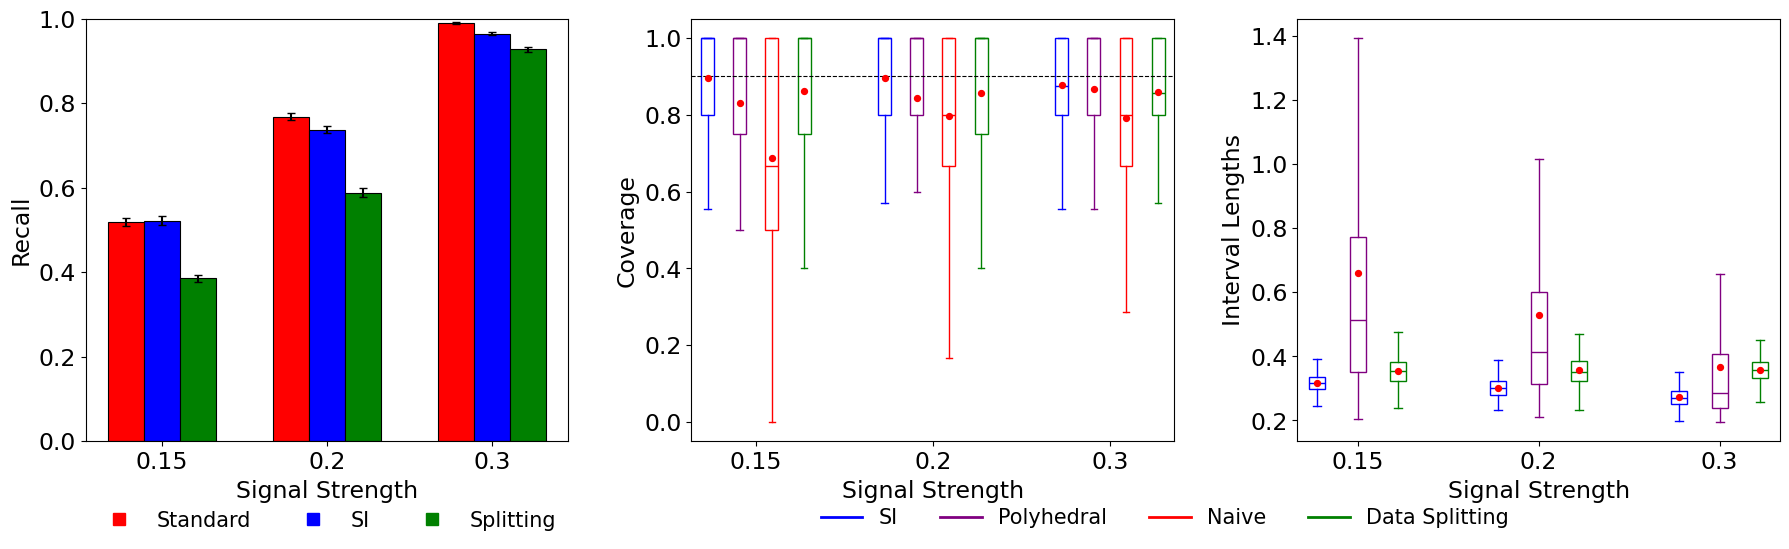

In [45]:
# df_signal = run_compwl_grid(
#     B=B,
#     fixed_N=60,
#     beta_11_values=(0.15, 0.2, 0.3),
#     randomizer_scale=np.sqrt(0.5),
#     mrt_kwargs=dict(nuisance="ols", corr=0.0),
# )
fig_signal, _ = plot_by_signal(df_signal)
fig_signal.savefig("fig_vary_signal.pdf", bbox_inches="tight")

### Vary sample size ($N$)

Figure *esplot*. $\beta_{11} = 0.20$, OLS nuisance, no cross-moderator correlation.

Polyhedral all-finite interval rates:
  N=30: 82.8% all-finite
  N=60: 86.8% all-finite
  N=90: 91.0% all-finite
  → Length panel: polyhedral filtered to all-finite only


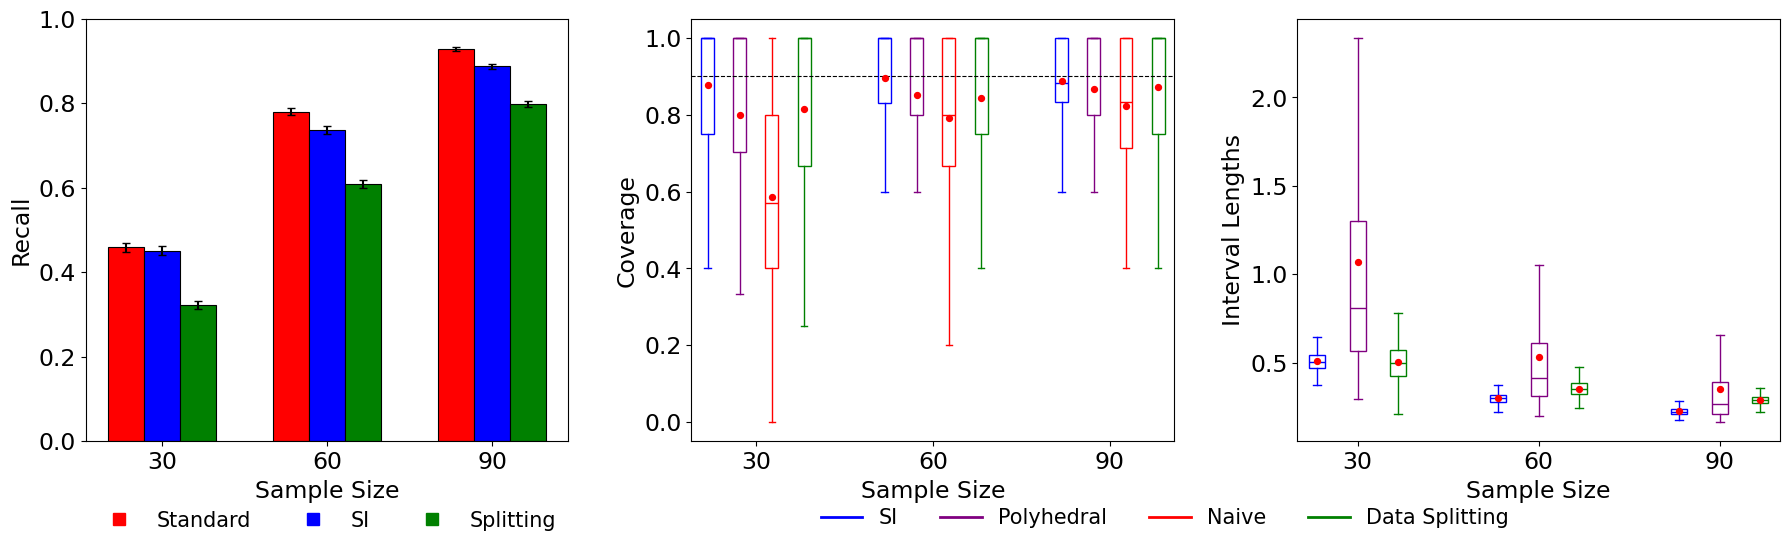

In [46]:
# df_N = run_compwl_grid(
#     B=B,
#     fixed_beta_11=0.20,
#     N_values=(30, 60, 90),
#     randomizer_scale=np.sqrt(0.5),
#     mrt_kwargs=dict(nuisance="ols", corr=0.0),
# )
fig_N, _ = plot_by_N(df_N)
fig_N.savefig("fig_vary_N.pdf", bbox_inches="tight")

### Vary randomization level ($\tau$)

Figure *tau_plot*. $N = 60$, $\beta_{11} = 0.20$; sweep
$\tau = \sqrt{\ell}\,\hat\sigma$ for $\ell \in \{0.5, 1, 2\}$.

N=60, beta11=0.2: 100%|██████████| 500/500 [09:21<00:00,  1.12s/it]

Polyhedral all-finite interval rate: 89.2%


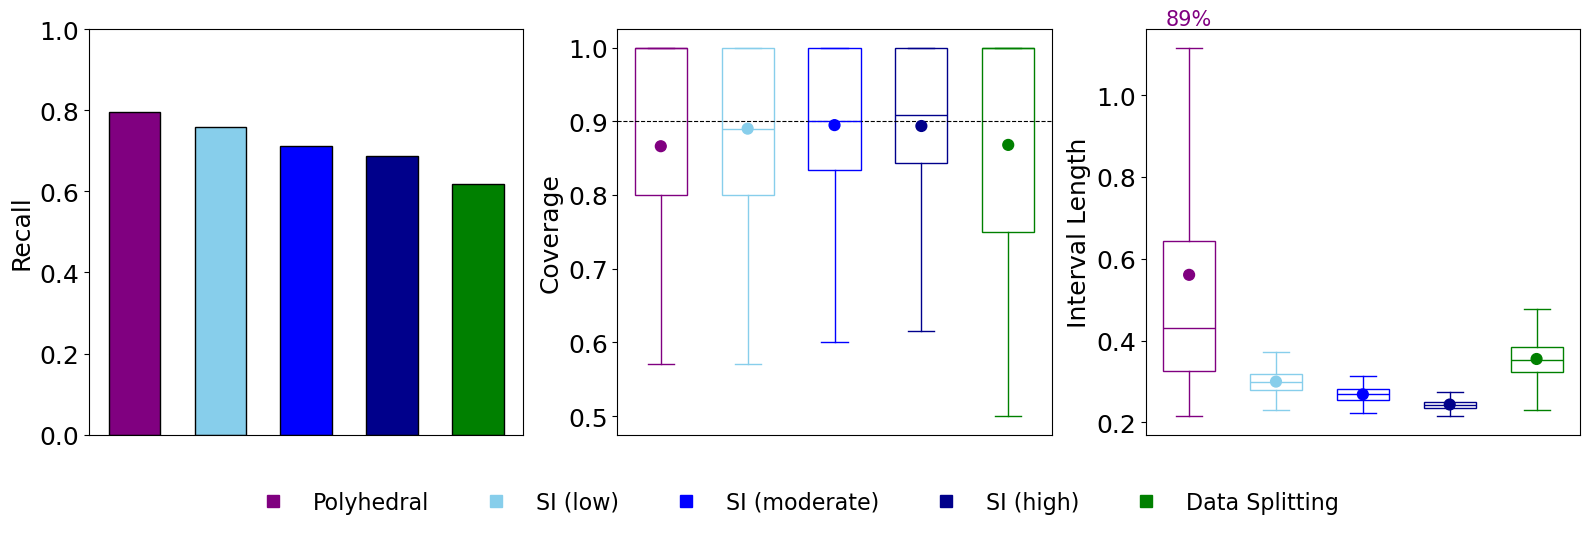

In [70]:
frames_tau = []
for l in [0.5, 1, 2]:
    df = run_compwl_grid(
        B=B, fixed_N=60, fixed_beta_11=0.2,
        randomizer_scale=np.sqrt(l),          # tau = sqrt(l) * sigma_hat
        mrt_kwargs=dict(nuisance="ols", corr=0.0),
    )
    df["tau_level"] = l
    frames_tau.append(df)

df_tau = pd.concat(frames_tau, ignore_index=True)
fig_tau, _ = plot_by_tau(df_tau)
# fig_tau.savefig("fig_vary_tau.pdf", bbox_inches="tight")

## Appendix F: robustness checks

### Cross-moderator correlation

Figure *corr_plot*. Vary the signal at correlation $r \in \{0, 0.5, 0.7\}$,
$N = 60$, with active moderators at indices $\{0, 10, 20, 30, 40\}$.

Polyhedral all-finite interval rates:
  corr=0.0: 85.8% all-finite
  corr=0.5: 86.4% all-finite
  corr=0.7: 77.0% all-finite
  → Length panel: polyhedral filtered to all-finite only


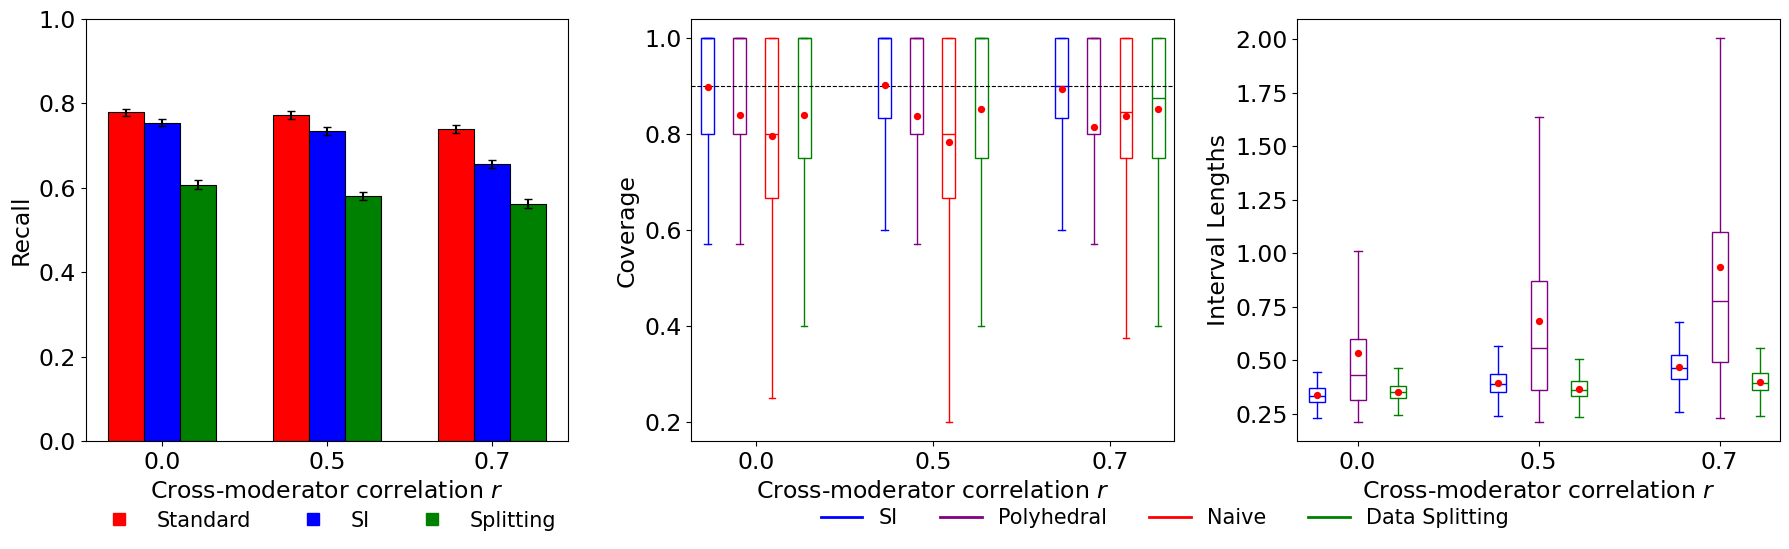

In [47]:
# frames_corr = []
# for r in [0.0, 0.5, 0.7]:
#     df = run_compwl_grid(
#         B=B, fixed_N=60, fixed_beta_11=0.2, randomizer_scale=np.sqrt(0.5),
#         mrt_kwargs=dict(nuisance="ols", corr=r,
#                         active_indices=[0, 10, 20, 30, 40]),
#     )
#     df["corr"] = r
#     frames_corr.append(df)

df_corr = pd.concat(frames_corr, ignore_index=True)
fig_corr, _ = plot_three_panel(df_corr, x="corr",
                               x_label="Cross-moderator correlation $r$")
fig_corr.savefig("fig_vary_signal_corr.pdf", bbox_inches="tight")

### Nuisance misspecification

Figure *misspec_plot*. Vary $N$ with misspecification strength $\gamma = 1.0$,
$\beta_{11} = 0.20$.

Polyhedral all-finite interval rates:
  N=30: 84.0% all-finite
  N=60: 88.2% all-finite
  N=90: 92.8% all-finite
  → Length panel: polyhedral filtered to all-finite only


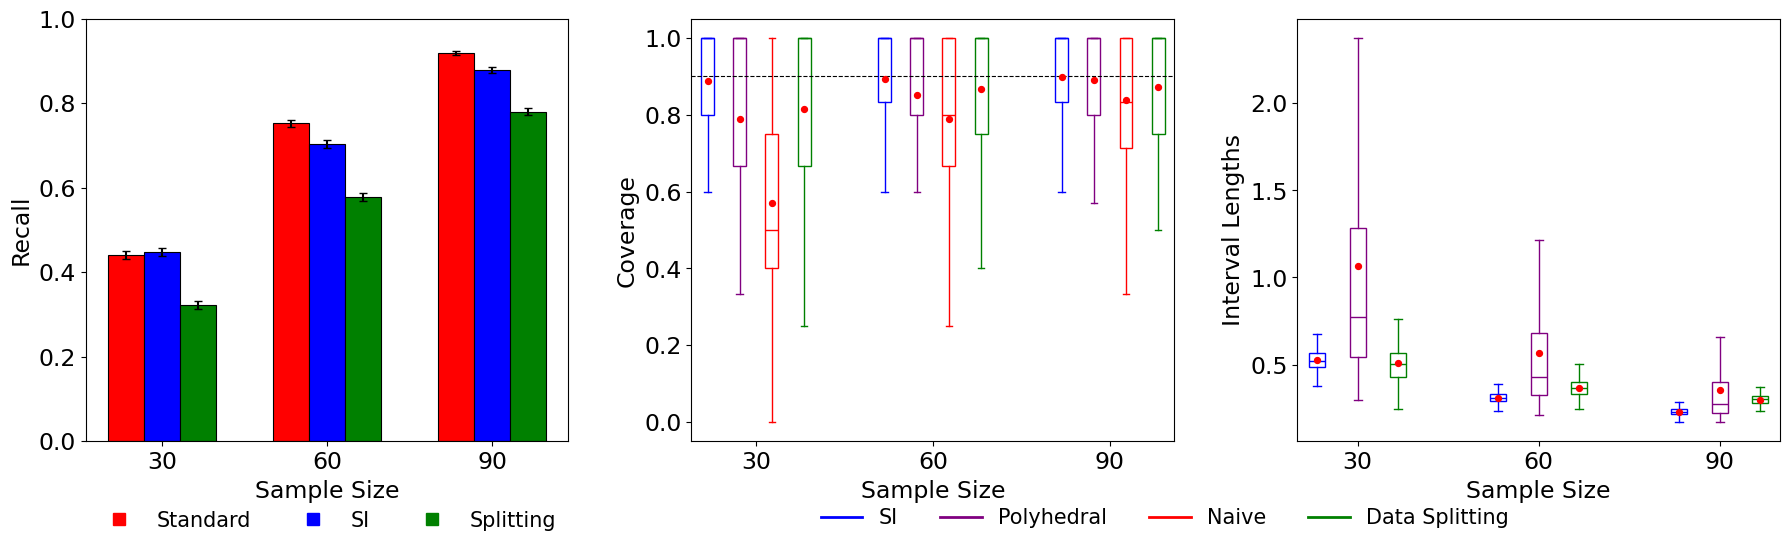

In [48]:
# df_N_misspec = run_compwl_grid(
#     B=B,
#     fixed_beta_11=0.2,
#     N_values=(30, 60, 90), randomizer_scale=np.sqrt(0.5),
#     mrt_kwargs=dict(nuisance="ols", corr=0.0, misspec_strength=1.0),
# )
fig_misspec, _ = plot_by_N(df_N_misspec)
fig_misspec
fig_misspec.savefig("fig_vary_N_misspecified.pdf", bbox_inches="tight")

### Non-Gaussian errors

Figures *laplace_plot* / *exp_plot*. Vary the signal at $N = 60$ with
Laplace and centered-exponential errors.

Polyhedral all-finite interval rates:
  beta_11=0.15: 87.4% all-finite
  beta_11=0.2: 89.0% all-finite
  beta_11=0.3: 92.2% all-finite
  → Length panel: polyhedral filtered to all-finite only


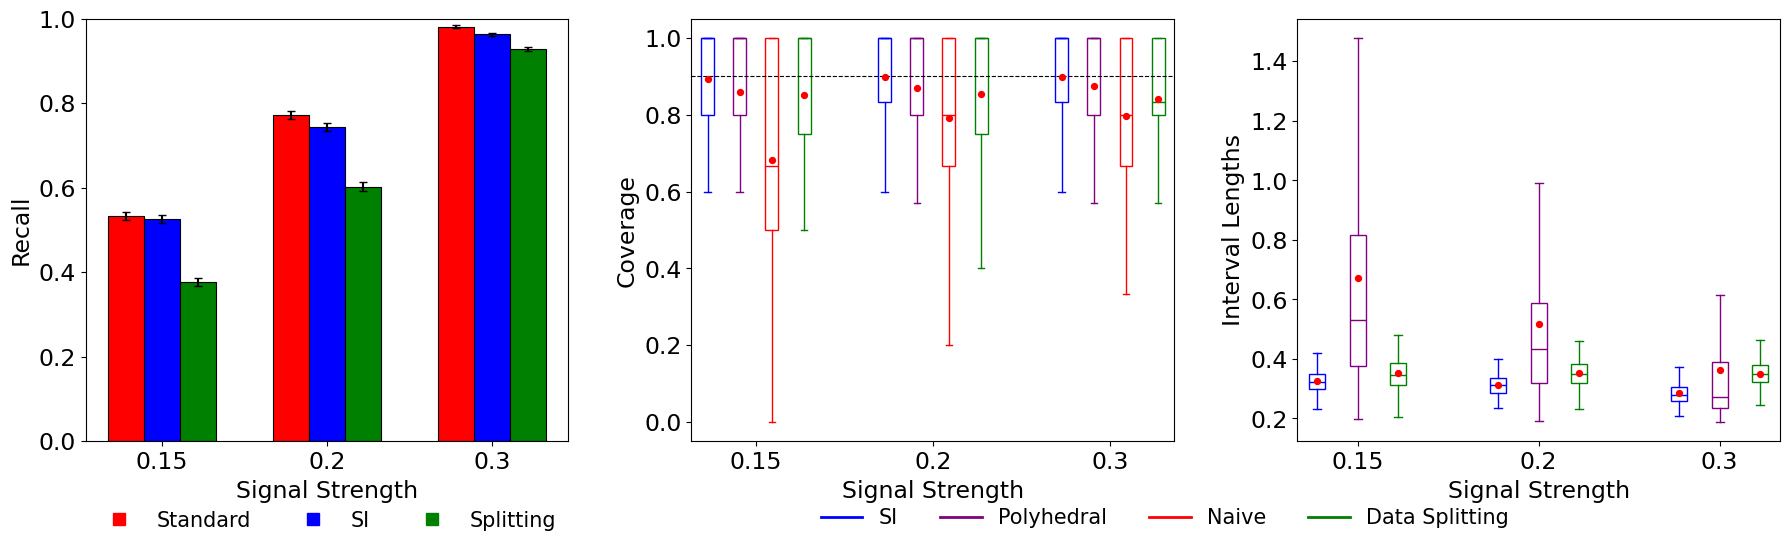

In [49]:
# df_laplace = run_compwl_grid(
#     B=B,
#     fixed_N=60,
#     beta_11_values=(0.15, 0.20, 0.30), randomizer_scale=np.sqrt(0.5),
#     mrt_kwargs=dict(nuisance="ols", corr=0.0, error_dist="laplace"),
# )
fig_laplace, _ = plot_by_signal(df_laplace)
fig_laplace
fig_laplace.savefig("fig_vary_signal_laplace.pdf", bbox_inches="tight")

Polyhedral all-finite interval rates:
  beta_11=0.15: 88.2% all-finite
  beta_11=0.2: 88.8% all-finite
  beta_11=0.3: 94.2% all-finite
  → Length panel: polyhedral filtered to all-finite only


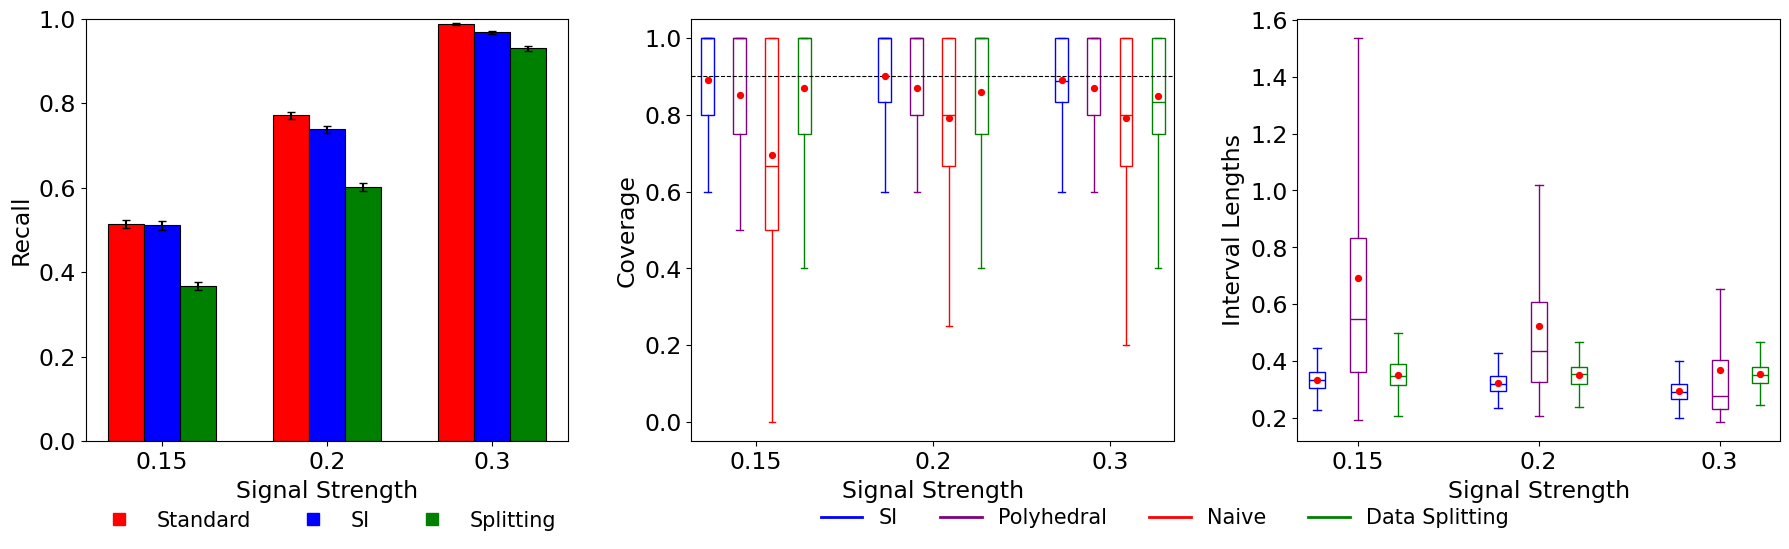

In [51]:
# df_exp = run_compwl_grid(
#     B=B,
#     fixed_N=60,
#     beta_11_values=(0.15, 0.20, 0.30),randomizer_scale=np.sqrt(0.5),
#     mrt_kwargs=dict(nuisance="ols", corr=0.0, error_dist="exponential"),
# )
fig_exp, _ = plot_by_signal(df_exp)
fig_exp
fig_exp.savefig("fig_vary_signal_exponential.pdf", bbox_inches="tight")

### Conditional coverage

Section AE.4. Baseline setting $N = 60$, $\beta_{11} = 0.2$; only moderators
selected in at least 5% of replications are shown.

In [55]:
raw_cc, summary_cc = run_conditional_coverage(
    B=B, N=60, beta_11=0.2,randomizer_scale=np.sqrt(0.5),
    methods=["randomized_si", "naive_gee", "data_splitting"],
    mrt_kwargs=dict(nuisance="ols", corr=0.0),
)
print_conditional_coverage(summary_cc)

fig_cc, _ = plot_conditional_coverage(summary_cc, min_sel_rate=0.00)
# fig_cc.savefig("fig_conditional_coverage.pdf", bbox_inches="tight")
# summary_cc.to_csv("conditional_coverage_table.csv", index=False)

condcov N=60, beta11=0.2:   1%|          | 5/500 [00:03<06:22,  1.30it/s]


KeyboardInterrupt: 

### Seed stability

Section R1.3. $K = 20$ randomization draws on a single fixed dataset
($N = 90$, $\beta_{11} = 0.2$).

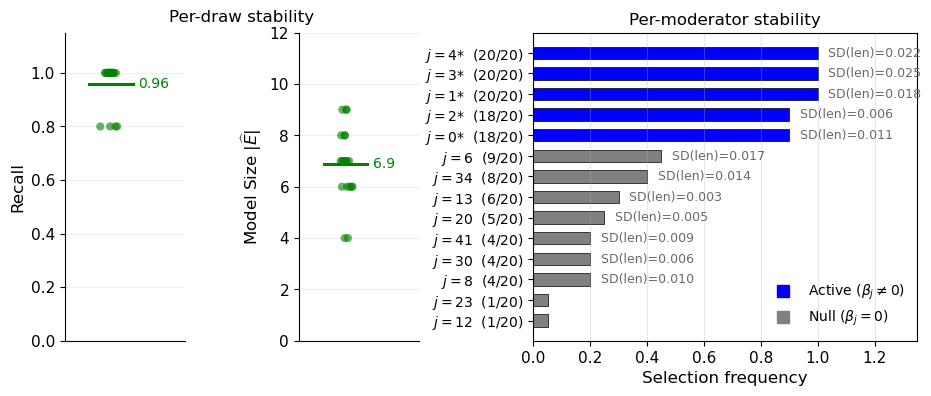

In [69]:
# seed_df, stability = run_seed_stability(
#     K=20, N=90, beta_11=0.2,
#     mrt_kwargs=dict(nuisance="ols", corr=0.0),
#     data_seed=42, randomizer_scale=np.sqrt(0.5),
# )
# print_seed_stability(stability)

fig_seed, _ = plot_seed_stability(stability, seed_df)
fig_seed.savefig("fig_seed_stability.pdf", bbox_inches="tight")
# seed_df.to_csv("seed_stability_raw.csv", index=False)

# VALENTINE data application

We apply the same three inference methods to the **VALENTINE** micro-randomized
trial (Section 6). The response is the (transformed) step count; the moderators
are time-varying context features.

`load_valentine_design` mirrors `MRT_instance` exactly:

1. one-hot encode categorical covariates and split the enrollment-time trend by phase;
2. optionally add **Phase $\times$ moderator** and **demographic $\times$ behavioral** interactions;
3. split individuals 1/3 (nuisance estimation) vs 2/3 (analysis);
4. residualize $Y$ against the OLS nuisance fit and form the WCLS design
   $X = (A-p)\cdot\text{covariates}$;
5. **standardize the design columns to unit SD.**

**What changed from the old notebook (and why it was selecting nothing).**

* The penalty is now the Negahban *score* penalty
  $\lambda = \texttt{mult}\cdot \operatorname{median}_b \max_j |X_j^\top \varepsilon^{(b)}|$,
  $\varepsilon \sim N(0,\hat\sigma^2 I)$, exactly as in `compwl_inf`. The old magic
  multipliers (25 / 400 / 94) were calibrated to a different scaling and are
  $\sim$25$\times$ too large here — they push $\lambda$ above $\max_j|X_j^\top Y|$, so the
  lasso selects nothing and `fixedLassoInf` raises *"lambda too large"*. The correct
  value is the theory-motivated **multiplier $\approx 1$**, tuned down to enlarge the
  reported set if desired.
* $\hat\sigma$ is the **residual SD of the OLS nuisance fit** (what `MRT_instance`
  returns for `nuisance="ols"`), *not* `Y.std()` and *not* an `n>2p` projection of the
  analysis $Y$. It is used for the penalty, the randomizer scale, and the polyhedral
  `sigma`. (The randomized-SI *variance* still comes from the GEE sandwich at
  `dispersion=1`, so no explicit dispersion multiply is needed.)
* Columns are **standardized**: the simulation's states are already homogeneous unit
  scale, but the real moderators span step counts in the thousands down to 0/1
  indicators. Without standardizing, a handful of large-magnitude covariates dominate
  the $\ell_1$ penalty and only 1–3 variables are ever selected. Standardizing makes
  multiplier $\approx 1$ behave as intended (selecting $\approx$5–9 moderators). The old
  ad-hoc $1/\sqrt{n}$ divide is dropped — it is a global constant that cancels out of
  selection and is superseded by per-column standardization.

Since there is no ground-truth $\beta$, we report the selected moderators and CI
**lengths** (on the standardized scale) rather than coverage.

## Helpers: design construction and inference

In [15]:
import textwrap

VALENTINE_CSV = "~/Documents/git/SI-MRT/realdata/AW_df.csv"

_BASE_VARIABLES = [
    "ParticipantIdentifier", "Value_tran", "Notification_c", "TimeEnrolled_days",
    "Phases", "Value_30min_before", "NotificationType", "Baseline_steps",
    "IsWeekend", "IsIndoor", "IsLossFramed", "IsSnow", "IsActivity",
    "Value_30min_before_tran", "AgeEnrollment_years", "Gender", "Race",
    "ExerciseTimeAgg_min", "WalkDistanceAgg_m", "StepsAgg_priorweek",
    "Value_tran_sd_week", "Value_tran_sd_priorweek", "Distance_m_0",
]

_PHASE_INTERACTION_VARS = [
    "Value_30min_before", "Baseline_steps", "IsSnow", "IsWeekend", "IsActivity",
    "Value_30min_before_tran", "ExerciseTimeAgg_min", "WalkDistanceAgg_m",
    "StepsAgg_priorweek", "Value_tran_sd_week", "Distance_m_0",
]

_CROSS_DEMOGRAPHIC = ["AgeEnrollment_years", "Gender_M", "Race_Caucasian",
                      "IsWeekend", "IsIndoor", "IsSnow"]
_CROSS_BEHAVIORAL = ["Value_30min_before", "Baseline_steps", "ExerciseTimeAgg_min",
                     "WalkDistanceAgg_m", "StepsAgg_priorweek", "Distance_m_0"]

# readable labels for the CI plots (interactions are expanded automatically)
_VALENTINE_LABELS = {
    "Value_30min_before": "Steps 30 min before",
    "Value_30min_before_tran": "Steps 30 min before (tran)",
    "Baseline_steps": "Baseline steps",
    "IsWeekend": "Weekend", "IsIndoor": "Indoor", "IsLossFramed": "Loss-framed",
    "IsSnow": "Snow", "IsActivity": "Activity suggestion",
    "AgeEnrollment_years": "Age at enrollment",
    "ExerciseTimeAgg_min": "Aggregated exercise time",
    "WalkDistanceAgg_m": "Aggregated walking distance",
    "StepsAgg_priorweek": "Aggregated prior-week steps",
    "Value_tran_sd_week": "Step SD (week)",
    "Value_tran_sd_priorweek": "Step SD (prior week)",
    "Distance_m_0": "6-min walk distance",
    "Race_Caucasian": "Race: Caucasian", "Gender_M": "Gender: M",
    "NotificationType_morning": "Morning notification",
    "Phase1": "Phase 1 time", "Phase2": "Phase 2 time", "Phase3": "Phase 3 time",
}


def _prettify(name):
    """Readable moderator label, expanding PhaseK_ and a_x_b interaction names."""
    if name in _VALENTINE_LABELS:
        return _VALENTINE_LABELS[name]
    for k in (1, 2, 3):
        pre = f"Phase{k}_"
        if name.startswith(pre):
            return f"Phase {k} x {_prettify(name[len(pre):])}"
    if "_x_" in name:
        a, b = name.split("_x_", 1)
        return f"{_prettify(a)} x {_prettify(b)}"
    return name.replace("_", " ")


def load_valentine_design(time_interactions=False, cross_interactions=False,
                          seed=420, standardize=True):
    """
    Build the residualized, treatment-centered VALENTINE design and the nuisance
    noise-scale estimate, mirroring MRT_instance():

      * sigma_hat = residual SD of the OLS nuisance fit on the 1/3 estimation split
        (exactly what MRT_instance returns for nuisance="ols"),
      * design X = (A - p) * covariates -- NOT divided by sqrt(n),
      * columns standardized to unit SD (so the Negahban penalty with multiplier ~ 1
        treats the heterogeneous-scale real moderators fairly).

    Returns
    -------
    X : (n, p) float array
    Y : (n,)  float array
    df : DataFrame           ["id", <covariates...>, "Y"]  (standardized design)
    names : Index
    sigma_hat : float        nuisance-OLS residual SD
    """
    data = pd.read_csv(VALENTINE_CSV)[_BASE_VARIABLES]
    data = data.replace([np.inf, -np.inf], np.nan).dropna()

    non_numeric = data.select_dtypes(include=["object"]).columns
    data = pd.get_dummies(data, columns=non_numeric, drop_first=True)

    for k in (1, 2, 3):
        data[f"Phase{k}"] = data["TimeEnrolled_days"] * (data["Phases"] == k).astype(int)

    if time_interactions or cross_interactions:
        for var in _PHASE_INTERACTION_VARS:
            for phase in ("Phase1", "Phase2", "Phase3"):
                data[f"{phase}_{var}"] = data[phase] * data[var]

    if cross_interactions:
        for dem in _CROSS_DEMOGRAPHIC:
            for beh in _CROSS_BEHAVIORAL:
                data[f"{dem}_x_{beh}"] = data[dem] * data[beh]

    data = data.drop(columns=["Phases", "TimeEnrolled_days"])

    # 1/3 estimation, 2/3 analysis, split by individual
    np.random.seed(seed)
    unique_ids = data["ParticipantIdentifier"].unique()
    est_ids = np.random.choice(unique_ids, size=int(len(unique_ids) * 1 / 3), replace=False)
    est_set = data[data["ParticipantIdentifier"].isin(est_ids)]
    rest_set = data[~data["ParticipantIdentifier"].isin(est_ids)]

    drop = ["ParticipantIdentifier", "Value_tran", "Notification_c"]
    covariates = [c for c in data.columns if c not in drop]

    # OLS nuisance fit on the estimation set; sigma_hat = residual SD (as in MRT_instance)
    ols = sm.OLS(est_set["Value_tran"], est_set[covariates].astype(float)).fit()
    alphahat = np.asarray(ols.params)
    sigma_hat = float(np.sqrt(np.sum(ols.resid ** 2) / max(float(ols.df_resid), 1.0)))

    Xraw = rest_set[covariates].astype(float)
    Y = rest_set["Value_tran"].to_numpy() - Xraw.to_numpy() @ alphahat

    # WCLS design: multiply each covariate by the centered treatment indicator
    Xc = Xraw.multiply(rest_set["Notification_c"], axis="index")

    if standardize:
        col_sd = Xc.std(axis=0).replace(0.0, 1.0)
        Xc = Xc / col_sd

    X = Xc.to_numpy(dtype="float64")
    Y = Y.astype("float64").reshape(-1)
    names = Xc.columns

    df = pd.DataFrame({"id": rest_set["ParticipantIdentifier"].to_numpy()})
    df = pd.concat([df, Xc.reset_index(drop=True)], axis=1)
    df["Y"] = Y
    return X, Y, df, names, sigma_hat


def _valentine_record(method, selected, names, intervals):
    selected = np.asarray(selected, dtype=bool)
    intervals = np.asarray(intervals, dtype=float)
    return {
        "method": method,
        "selected": selected,
        "names": np.asarray(names)[selected],
        "intervals": intervals,
        "length": intervals[:, 1] - intervals[:, 0],
    }


def valentine_inference(X, Y, df, names, sigma_hat,
                        penalty_multiplier=1.0,
                        randomizer_scale=np.sqrt(0.5),
                        test_prop=0.3,
                        split_seed=420,
                        alpha=0.1,
                        n_score_draws=2000,
                        verbose=True):
    """
    Polyhedral / randomized SI / data splitting on a VALENTINE design, using the
    same conventions as compwl_inf():

      * penalty  W = penalty_multiplier * median_b max_j |X_j^T eps^(b)|,
        eps ~ N(0, sigma_hat^2)   (Negahban score penalty; multiplier ~ 1),
      * randomized SI with tau = randomizer_scale * sqrt(mean_diag) * sigma_hat
        and selective inference at dispersion=1 (GEE sandwich variance),
      * polyhedral (Lee et al. 2016) with sigma = sigma_hat.

    Returns {method: {selected, names, intervals, length}}.
    """
    n, p = X.shape

    # shared Negahban penalty (same sigma_hat everywhere)
    W = _score_penalty(X, Y, sigma=sigma_hat,
                       multiplier=penalty_multiplier, n_score_draws=n_score_draws)

    out = {}

    # 1. Polyhedral (Lee et al. 2016)
    slf = linear_model.Lasso(alpha=W / n, fit_intercept=False, max_iter=50000, tol=1e-8)
    slf.fit(X, Y)
    sel_p = slf.coef_ != 0
    res_p = selectiveInference.fixedLassoInf(X, Y, slf.coef_, lam=W, sigma=sigma_hat)
    ci_p = np.array(res_p.rx2("ci"))
    out["polyhedral"] = _valentine_record("polyhedral", sel_p, names, ci_p)

    # 2. Randomized SI (ours) -- tau and dispersion=1 exactly as in compwl_inf
    mean_diag = np.mean((X ** 2).sum(0))
    tau = randomizer_scale * np.sqrt(mean_diag) * sigma_hat
    conv = lasso.gaussian(X, Y, W, ridge_term=0.0, randomizer_scale=tau)
    sel_si = conv.fit() != 0
    conv.setup_inference(dispersion=1)
    target_spec = selected_targets_WCLS(conv.loglike, df, conv.observed_soln,
                                        K=conv.K, dispersion=1)
    res_si = conv.inference(target_spec)
    ci_si = np.asarray(res_si[["lower_confidence", "upper_confidence"]])
    out["randomized_si"] = _valentine_record("randomized_si", sel_si, names, ci_si)

    # 3. Data splitting -- lasso on train, GEE-robust CIs on test
    train_ids, test_ids = _split_ids(df, test_prop=test_prop, seed=split_seed)
    A_train = df[df["id"].isin(train_ids)]
    A_test = df[df["id"].isin(test_ids)]
    X_train = np.asarray(A_train.iloc[:, 1:-1])
    Y_train = np.asarray(A_train.iloc[:, -1])
    n_train = X_train.shape[0]
    W_train = _score_penalty(X_train, Y_train, sigma=sigma_hat,
                             multiplier=penalty_multiplier, n_score_draws=n_score_draws)
    slf2 = linear_model.Lasso(alpha=W_train / n_train, fit_intercept=False,
                              max_iter=50000, tol=1e-8)
    slf2.fit(X_train, Y_train)
    sel_split = slf2.coef_ != 0
    Xf = np.asarray(A_test.iloc[:, 1:-1])[:, sel_split]
    model = sm.GEE(A_test["Y"], Xf, groups=A_test["id"],
                   family=sm.families.Gaussian(),
                   cov_struct=sm.cov_struct.Independence())
    ci_split = np.asarray(model.fit(cov_type="robust").conf_int(alpha=alpha))
    out["data_splitting"] = _valentine_record("data_splitting", sel_split, names, ci_split)

    if verbose:
        print(f"lambda W = {W:.4g}   (sigma_hat = {sigma_hat:.4g}, n = {n}, p = {p})")
        for m in ("polyhedral", "randomized_si", "data_splitting"):
            r = out[m]
            avg = np.nanmean(r["length"]) if r["length"].size else float("nan")
            print(f"{METHOD_LABELS[m]:>14s}: {int(r['selected'].sum()):2d} selected, "
                  f"avg CI length {avg:.4f}")
            print(f"{'':14s}  {[_prettify(s) for s in r['names']]}")
    return out


def plot_valentine(results, display=None, pretty=None,
                   methods=("randomized_si", "polyhedral", "data_splitting"),
                   focus_methods=("randomized_si", "data_splitting"),
                   title=None, figsize=(13, 8), fontsize=16, wrap=20,
                   rotation=30, ylim=None, pad_frac=0.15, spacing=0.22):
    """
    Overlay the methods' CIs for the SI-selected moderators, ordered left-to-right
    by cross-method agreement:

        1. moderators with a finite CI from *all* methods,
        2. moderators selected by our method (SI) and data splitting,
        3. moderators selected by our method only.

    Only finite intervals are drawn. The bars at each moderator are centered on
    its x-label, so a lone SI bar sits directly above the tick (no empty slots).
    """
    def _finite(ci):
        return ci is not None and np.all(np.isfinite(ci))

    lut = {m: dict(zip(results[m]["names"], results[m]["intervals"])) for m in methods}

    if display is None:
        # SI-selected moderators that have a finite SI interval
        si = [nm for nm in results["randomized_si"]["names"]
              if _finite(lut["randomized_si"].get(nm))]

        def _key(nm):
            k = sum(_finite(lut[m].get(nm)) for m in methods)       # agreeing methods
            ds = _finite(lut["data_splitting"].get(nm))             # DS preferred on ties
            return (-k, 0 if ds else 1, nm)

        display = sorted(si, key=_key)

    pretty = pretty or {}
    labels = [pretty.get(nm, _prettify(nm)) for nm in display]
    wrapped = ["\n".join(textwrap.wrap(str(l), width=wrap)) for l in labels]
    x = np.arange(len(display))

    # Zoom: base the y-range on the tight (focus) methods, always including 0.
    if ylim is None:
        pts = [v for m in focus_methods for nm in display
               if _finite(lut[m].get(nm)) for v in lut[m][nm]]
        if not pts:
            pts = [v for m in methods for nm in display
                   if _finite(lut[m].get(nm)) for v in lut[m][nm]]
        if pts:
            lo, hi = min(pts + [0.0]), max(pts + [0.0])
            pad = pad_frac * (hi - lo) if hi > lo else 1.0
            ylim = (lo - pad, hi + pad)

    fig, ax = plt.subplots(figsize=figsize)
    labeled = set()
    cap = spacing * 0.28
    for i, nm in enumerate(display):
        present = [m for m in methods if _finite(lut[m].get(nm))]
        k = len(present)
        for j, m in enumerate(present):
            ci = lut[m][nm]
            xc = x[i] + (j - (k - 1) / 2.0) * spacing   # centered on the tick
            lab = METHOD_LABELS[m] if m not in labeled else ""
            ax.plot([xc, xc], ci, color=METHOD_COLORS[m], linewidth=2.2,
                    solid_capstyle="round", label=lab)
            ax.plot(xc, (ci[0] + ci[1]) / 2, "o", color=METHOD_COLORS[m], markersize=5)
            ax.plot([xc - cap, xc + cap], [ci[0], ci[0]], color=METHOD_COLORS[m], linewidth=2.2)
            ax.plot([xc - cap, xc + cap], [ci[1], ci[1]], color=METHOD_COLORS[m], linewidth=2.2)
            labeled.add(m)

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xlim(-0.5, len(display) - 0.5)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xticks(x)
    ax.set_xticklabels(wrapped, fontsize=fontsize, rotation=rotation, ha="right",
                       rotation_mode="anchor")
    ax.tick_params(axis="y", labelsize=fontsize)
    ax.set_ylabel("Confidence interval (standardized)", fontsize=fontsize)
    if title:
        ax.set_title(title, fontsize=fontsize + 4)
    # legend in canonical method order
    handles, lbls = ax.get_legend_handles_labels()
    hd = dict(zip(lbls, handles))
    order = [METHOD_LABELS[m] for m in methods if METHOD_LABELS[m] in hd]
    if order:
        ax.legend([hd[o] for o in order], order, fontsize=fontsize, frameon=True)
    ax.grid(axis="y", alpha=0.25)
    fig.subplots_adjust(bottom=0.32)
    plt.tight_layout()
    return fig, ax


# ============================================================
# JASA-style LaTeX summary table
# ============================================================


def _tex_escape(s):
    for a, b in [("\\", r"\textbackslash{}"), ("&", r"\&"), ("%", r"\%"),
                 ("_", r"\_"), ("#", r"\#"), ("$", r"\$")]:
        s = s.replace(a, b)
    return s


def _names_tex(names, pretty=None, max_names=None):
    pretty = pretty or {}
    labs = [pretty.get(nm, _prettify(nm)) for nm in names]
    if not labs:
        return "--"
    truncated = max_names is not None and len(labs) > max_names
    if truncated:
        labs = labs[:max_names]
    out = ", ".join(_tex_escape(l) for l in labs)
    return out + (r", \dots" if truncated else "")


def valentine_latex_table(settings, alpha=0.1, pretty=None,
                          caption=None, label="tab:valentine",
                          name_width="4.3cm", sig_width="3.7cm",
                          max_names=None):
    """
    JASA-style LaTeX table summarizing the VALENTINE analysis.

    Parameters
    ----------
    settings : mapping {setting_name: results} or list of (name, results) pairs,
               where `results` is the output of valentine_inference().

    Layout: rows grouped by setting (candidate moderator set); within each
    setting one row per method (SI, DS, Polyhedral) reporting

        Selected moderators | Avg. (finite) CI length | Significant moderators (sign)

    A moderator is "significant" when its CI excludes 0; the sign is that of the
    moderated effect. Average length is over finite intervals only (polyhedral
    can return one-sided-infinite CIs). Requires \\usepackage{booktabs} and
    \\usepackage{multirow}.
    """
    if hasattr(settings, "items"):
        settings = list(settings.items())
    method_rows = [("SI", "randomized_si"), ("DS", "data_splitting"),
                   ("Polyhedral", "polyhedral")]

    if caption is None:
        caption = ("VALENTINE analysis: moderators selected by each method, "
                   "average selective confidence-interval length, and significant "
                   "moderators (sign of the moderated effect in parentheses), by "
                   "candidate moderator set. Confidence level $1-\\alpha=%.2f$." % (1 - alpha))

    lines = [r"% Requires \usepackage{booktabs} and \usepackage{multirow}",
             r"\begin{table}[t]", r"\centering",
             r"\caption{" + caption + r"}",
             r"\label{" + label + r"}",
             r"\small",
             r"\begin{tabular}{ll p{%s} c p{%s}}" % (name_width, sig_width),
             r"\toprule",
             r"Setting & Method & Selected moderators & Avg.\ length & "
             r"Significant moderators \\",
             r"\midrule"]

    for s_idx, (sname, res) in enumerate(settings):
        for r_idx, (mlabel, mkey) in enumerate(method_rows):
            names = list(res[mkey]["names"])
            ivs = np.asarray(res[mkey]["intervals"], dtype=float)

            if len(ivs):
                lengths = ivs[:, 1] - ivs[:, 0]
                fin = lengths[np.isfinite(lengths)]
                avg = ("%.3f" % np.mean(fin)) if fin.size else "--"
            else:
                avg = "--"

            sig = []
            for nm, ci in zip(names, ivs):
                lo, hi = ci[0], ci[1]
                if lo > 0:
                    sig.append((nm, "$+$"))
                elif hi < 0:
                    sig.append((nm, "$-$"))
            pretty_ = pretty or {}
            sig_tex = ", ".join(
                "%s (%s)" % (_tex_escape(pretty_.get(nm, _prettify(nm))), d)
                for nm, d in sig
            ) or "--"

            sel_tex = _names_tex(names, pretty=pretty, max_names=max_names)
            first = (r"\multirow{3}{*}{%s}" % _tex_escape(sname)) if r_idx == 0 else ""
            lines.append(r"%s & %s & %s & %s & %s \\" %
                         (first, mlabel, sel_tex, avg, sig_tex))

        lines.append(r"\midrule" if s_idx < len(settings) - 1 else r"\bottomrule")

    lines += [r"\end{tabular}", r"\end{table}"]
    return "\n".join(lines)


def valentine_significant_table(settings, pretty=None,
                                caption=None, label="tab:valentine_significant",
                                setting_sizes=None, si_width="5cm", ds_width="4.5cm"):
    """
    Simple LaTeX table of *robust significant* moderators (selective CI excludes 0),
    with the sign of the moderated effect, by setting, in two sub-columns (SI, DS).
    Polyhedral is omitted because its intervals are infinite in this application.

    settings      : mapping {setting_name: results} or list of (name, results).
    setting_sizes : optional {setting_name: p} to annotate candidate counts.
    Requires \\usepackage{booktabs}.
    """
    if hasattr(settings, "items"):
        settings = list(settings.items())
    setting_sizes = setting_sizes or {}
    prettyf = pretty or {}

    def _sig(res, mkey):
        names = list(res[mkey]["names"])
        ivs = np.asarray(res[mkey]["intervals"], dtype=float)
        out = []
        for nm, ci in zip(names, ivs):
            lo, hi = ci[0], ci[1]
            lab = _tex_escape(prettyf.get(nm, _prettify(nm)))
            if lo > 0:
                out.append("%s ($+$)" % lab)
            elif hi < 0:
                out.append("%s ($-$)" % lab)
        return ", ".join(out) or "---"

    if caption is None:
        caption = ("Robust significant moderators (90\\% selective confidence "
                   "intervals excluding zero; sign of the moderated effect in "
                   "parentheses) in the VALENTINE analysis, by candidate moderator "
                   "set. Polyhedral intervals are omitted as they are infinite here.")

    lines = [r"% Requires \usepackage{booktabs}",
             r"\begin{table}[t]", r"\centering",
             r"\caption{" + caption + r"}",
             r"\label{" + label + r"}",
             r"\begin{tabular}{l p{%s} p{%s}}" % (si_width, ds_width),
             r"\toprule",
             r" & \multicolumn{2}{c}{Robust significant moderators} \\",
             r"\cmidrule(lr){2-3}",
             r"Setting & By SI & By data splitting \\",
             r"\midrule"]
    for sname, res in settings:
        sz = setting_sizes.get(sname)
        s_lab = ("%s (%d)" % (_tex_escape(sname), sz)) if sz else _tex_escape(sname)
        lines.append(r"%s & %s & %s \\" %
                     (s_lab, _sig(res, "randomized_si"), _sig(res, "data_splitting")))
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    return "\n".join(lines)

## Main-effects model

No interactions: the treatment is moderated by the raw context features
(25 candidate moderators). `penalty_multiplier=1` is the Negahban value; raise it
to shrink the selected set, lower it to enlarge it.

In [16]:
X, Y, df, names, sigma_hat = load_valentine_design(seed=42)
print("n, p =", X.shape, " sigma_hat =", round(sigma_hat, 4))

res_main = valentine_inference(
    X, Y, df, names, sigma_hat,
    penalty_multiplier=1.0, test_prop=0.3, split_seed=42,
)

n, p = (15905, 25)  sigma_hat = 1.193
lambda W = 295   (sigma_hat = 1.193, n = 15905, p = 25)
    Polyhedral:  9 selected, avg CI length inf
                ['Weekend', 'Indoor', 'Activity suggestion', 'Aggregated prior-week steps', 'Step SD (prior week)', '6-min walk distance', 'Morning notification', 'Phase 2 time', 'Phase 3 time']
            SI:  6 selected, avg CI length 0.1383
                ['Weekend', 'Indoor', 'Aggregated walking distance', 'Step SD (prior week)', 'Phase 2 time', 'Phase 3 time']
Data Splitting:  9 selected, avg CI length 0.3226
                ['Weekend', 'Indoor', 'Activity suggestion', 'Aggregated prior-week steps', 'Step SD (prior week)', '6-min walk distance', 'NotificationType evening', 'Race: Caucasian', 'Phase 3 time']


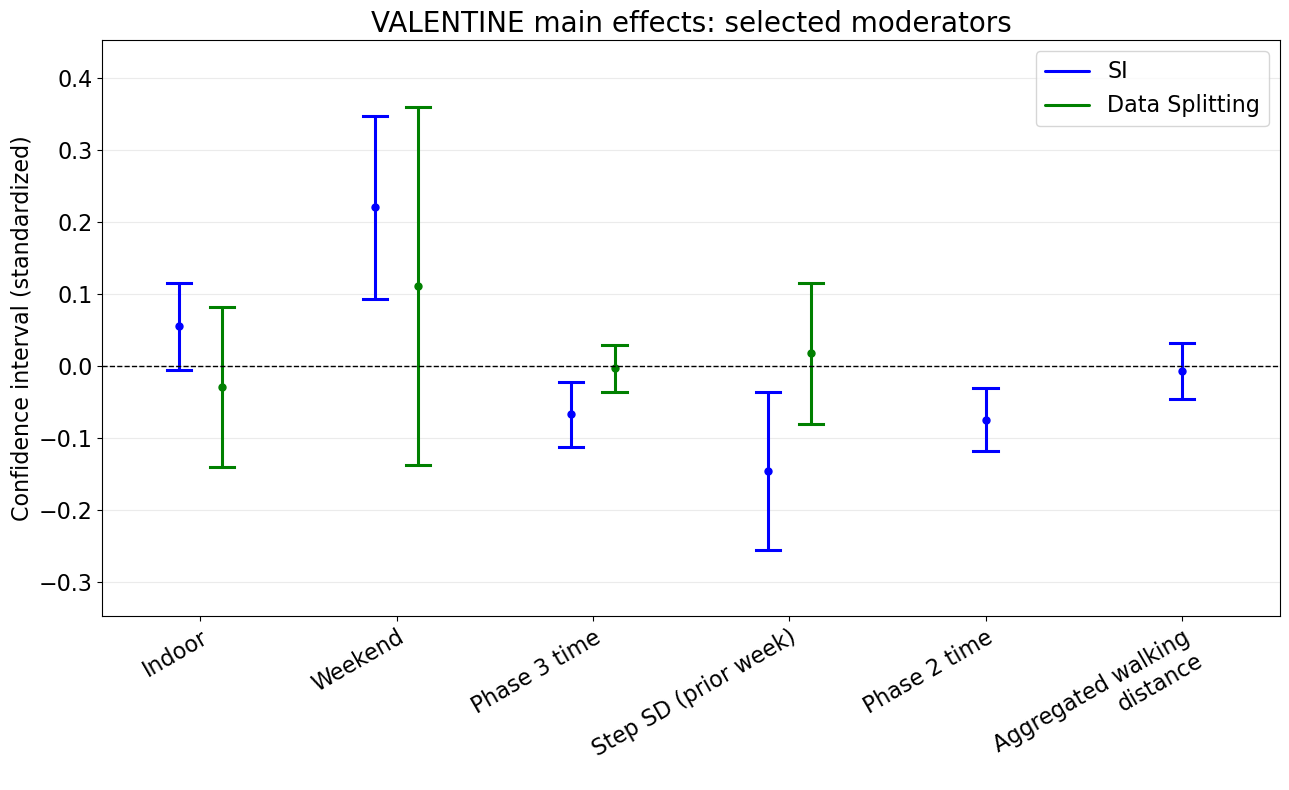

In [13]:
fig_val_main, _ = plot_valentine(
    res_main, title="VALENTINE main effects: selected moderators",
)
# fig_val_main.savefig("fig_valentine_main.pdf", bbox_inches="tight")

## Phase (time) interactions

Add Phase $\times$ moderator interactions, letting the moderated effect vary
across the three study phases (58 candidate moderators).

In [16]:
X, Y, df, names, sigma_hat = load_valentine_design(time_interactions=True, seed=42)
print("n, p =", X.shape, " sigma_hat =", round(sigma_hat, 4))

res_time = valentine_inference(
    X, Y, df, names, sigma_hat,
    penalty_multiplier=1.0, test_prop=0.3, split_seed=42,
)

n, p = (15905, 58)  sigma_hat = 1.164
lambda W = 322.5   (sigma_hat = 1.164, n = 15905, p = 58)
    Polyhedral:  4 selected, avg CI length inf
                ['Weekend', 'Phase 1 x Weekend', 'Phase 3 x Activity suggestion', 'Phase 3 x 6-min walk distance']
            SI:  4 selected, avg CI length 0.0612
                ['Phase 1 x Snow', 'Phase 1 x Weekend', 'Phase 2 x Activity suggestion', 'Phase 3 x Activity suggestion']
Data Splitting:  5 selected, avg CI length 0.0812
                ['Weekend', 'Phase 1 x Snow', 'Phase 1 x Weekend', 'Phase 3 x Activity suggestion', 'Phase 3 x 6-min walk distance']


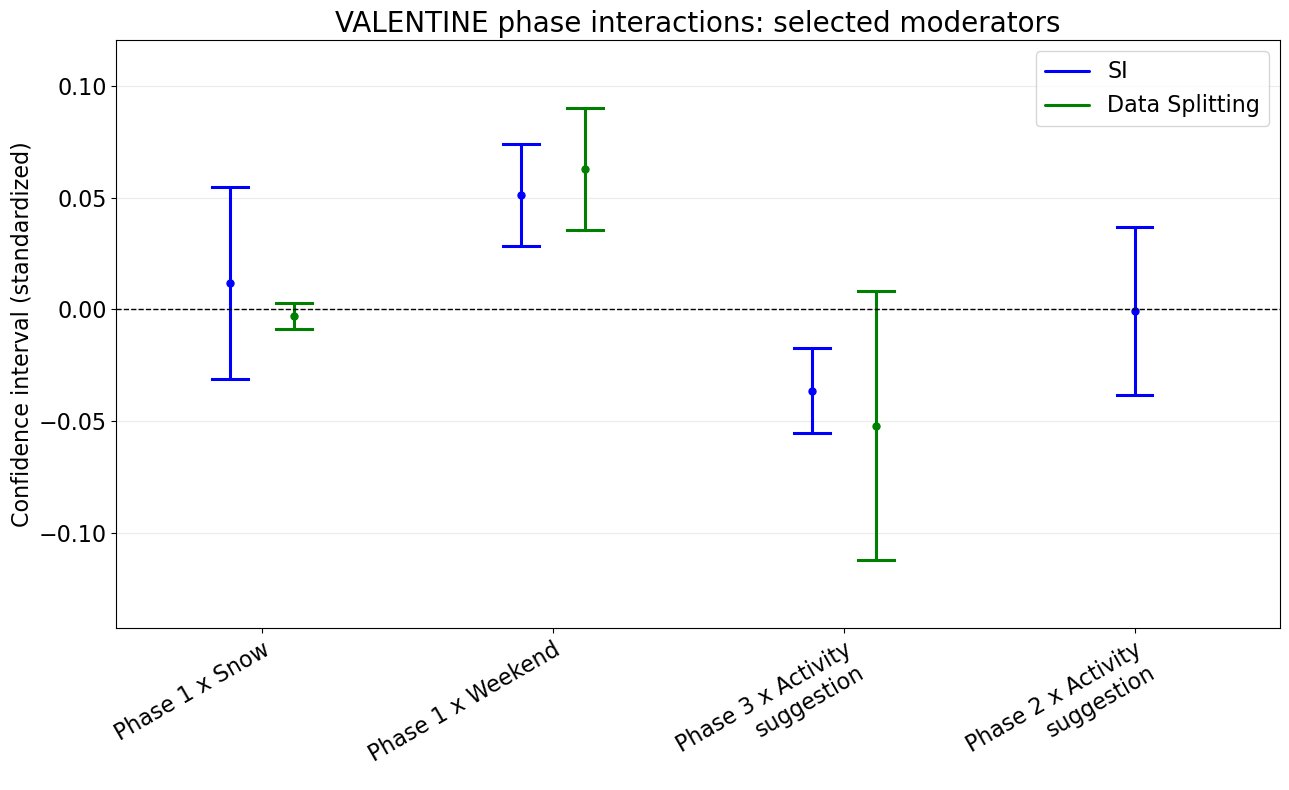

In [32]:
fig_val_time, _ = plot_valentine(
    res_time, title="VALENTINE phase interactions: selected moderators",
)
# fig_val_time.savefig("fig_valentine_time.pdf", bbox_inches="tight")

## Extended interactions

Phase $\times$ moderator interactions **plus** demographic $\times$ behavioral
cross-interactions (94 candidate moderators).

In [18]:
X, Y, df, names, sigma_hat = load_valentine_design(
    time_interactions=True, cross_interactions=True, seed=42,
)
print("n, p =", X.shape, " sigma_hat =", round(sigma_hat, 4))

res_ext = valentine_inference(
    X, Y, df, names, sigma_hat,
    penalty_multiplier=1.5, test_prop=0.3, split_seed=42,
)

n, p = (15905, 94)  sigma_hat = 1.1563
lambda W = 500.9   (sigma_hat = 1.156, n = 15905, p = 94)
    Polyhedral:  3 selected, avg CI length inf
                ['Phase 1 x Weekend', 'Phase 3 x Activity suggestion', 'Snow x Aggregated prior-week steps']
            SI:  4 selected, avg CI length 0.1427
                ['Phase 3 x Activity suggestion', 'Phase 1 x 6-min walk distance', 'Gender: M x Steps 30 min before', 'Snow x Baseline steps']
Data Splitting:  7 selected, avg CI length 0.2594
                ['Step SD (week)', 'Phase 3 x Activity suggestion', 'Weekend x Aggregated prior-week steps', 'Weekend x 6-min walk distance', 'Indoor x Aggregated walking distance', 'Indoor x Aggregated prior-week steps', 'Snow x Aggregated prior-week steps']


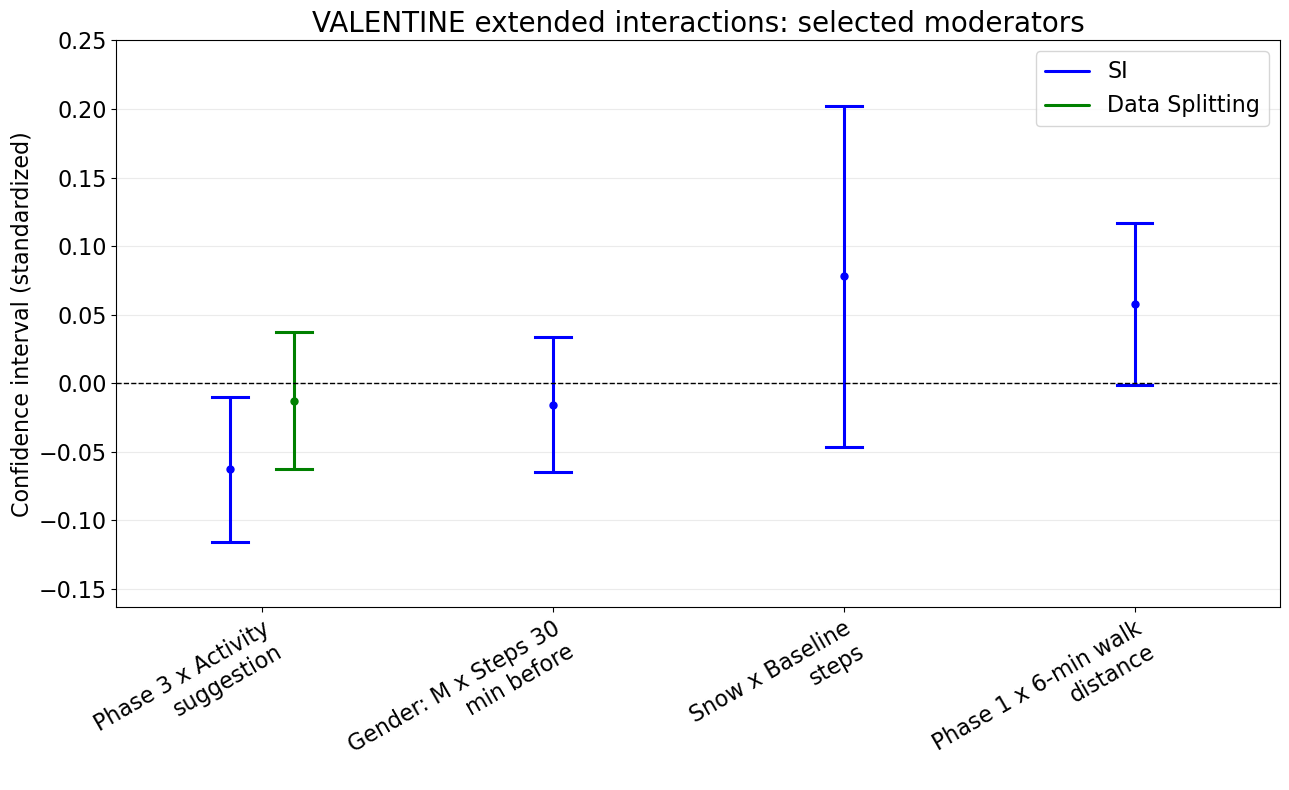

In [19]:
fig_val_ext, _ = plot_valentine(
    res_ext, title="VALENTINE extended interactions: selected moderators",
)
# fig_val_ext.savefig("fig_valentine_extended.pdf", bbox_inches="tight")

## Significant moderators (LaTeX)

Simple table across the three candidate moderator sets: the robust significant
moderators (90% selective CIs excluding zero), with the sign of the moderated
effect, in two sub-columns (SI, DS). Polyhedral is omitted (its intervals are
infinite in this application). Paste the printed LaTeX into the paper appendix
(needs `booktabs`).

In [33]:
settings = {
    "Main effects": res_main,
    "Phase interactions": res_time,
    "Extended interactions": res_ext,
}
sizes = {"Main effects": 25, "Phase interactions": 58, "Extended interactions": 94}
print(valentine_significant_table(settings, setting_sizes=sizes,
                                  label="tab:valentine_significant"))

% Requires \usepackage{booktabs}
\begin{table}[t]
\centering
\caption{Robust significant moderators (90\% selective confidence intervals excluding zero; sign of the moderated effect in parentheses) in the VALENTINE analysis, by candidate moderator set. Polyhedral intervals are omitted as they are infinite here.}
\label{tab:valentine_significant}
\begin{tabular}{l p{5cm} p{4.5cm}}
\toprule
 & \multicolumn{2}{c}{Robust significant moderators} \\
\cmidrule(lr){2-3}
Setting & By SI & By data splitting \\
\midrule
Main effects (25) & Weekend ($+$), Step SD (prior week) ($-$), Phase 2 time ($-$), Phase 3 time ($-$) & --- \\
Phase interactions (58) & Phase 1 x Weekend ($+$), Phase 3 x Activity suggestion ($-$) & Phase 1 x Weekend ($+$) \\
Extended interactions (94) & Phase 3 x Activity suggestion ($-$) & Indoor x Aggregated walking distance ($+$), Indoor x Aggregated prior-week steps ($-$), Snow x Aggregated prior-week steps ($-$) \\
\bottomrule
\end{tabular}
\end{table}
